In [ ]:
! pip install pypsa highspy openpyxl "xarray<=2024.9.0"

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
# Import packages
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import json
import time
import pypsa
import warnings

ROOT_DIR = os.getcwd()
PROJECT_DIR = os.path.join(ROOT_DIR, "drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model")


In [ ]:
sys.path.append(PROJECT_DIR)

from modules.getting_input_data import get_input_data

input_file_name = "input_file.xlsx"
input_data = get_input_data(PROJECT_DIR, input_file_name)

File found at: /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/input_file.xlsx
The input data has been imported.


In [ ]:
zones = json.loads(input_data["zones"])
year = input_data["year"]
scenario =  input_data["scenario"]
project_name =  input_data["project_name"]


INTER_DIR = os.path.join(PROJECT_DIR, str(input_data["data_set"]),input_data["subfolder"],input_data["project_name"], input_data["scenario"], str(input_data["year"]))
DATA_DIR = os.path.join(PROJECT_DIR, str(input_data["data_set"]),input_data["data_dir"])


capacities = {}

In [ ]:
input_data

{'project_name': 'Italy',
 'regions': '["Austria","Italy","Slovenia"]',
 'zones': '["ITCA","ITCN","ITCS","ITS1","ITN1","ITSA","ITSI","AT00","SI00"]',
 'data_set': 2024,
 'year': 2040,
 'scenario': 'GA',
 'weather_year': 2010,
 'subfolder': 'intermediate_data',
 'data_dir': 'input_data',
 'result_dir': 'results',
 'FLEX': True,
 'NTC': True,
 'H2': True,
 'CH4': True,
 'HEAT': False,
 'gas_infra_level': 'LOW',
 'Synthetic_fuels': False,
 'share': 0.5,
 'prefix': '/content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model',
 'input_data_path': '/content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/input_file.xlsx'}

# Reading Itermediate_data Folder

Most data is imported from the intermediate_data folder, specifically:
*   Generation capacities
*   RES profiles
*   Hydrogen data
*   Demand profiles

The only exception is NTC data - electricity and hydrogen, which is sourced directly from the raw data folder.

## 1, Capacities

In [ ]:
# Define the path to the capacities file
capacities_file_path = os.path.join(INTER_DIR, f"capacity_{year}.json")

# Load the capacities data
try:
    with open(capacities_file_path, 'r') as f:
        capacities = json.load(f)
    print(f"✅ Successfully loaded capacities for {project_name} project in {year}.")
    zones = list(capacities.keys())
    print(f"    Zones are:", zones)
except FileNotFoundError:
    print(f"❌ Error: The file {os.path.basename(capacities_file_path)} was not found. Please ensure it's in the correct directory ({os.path.join(PROJECT_DIR, project_name)}).")
    # Diagnostic: List files in the project directory to help the user
    print(f"Files in {os.path.join(PROJECT_DIR, project_name)}:")
    try:
        for item in os.listdir(os.path.join(PROJECT_DIR, project_name)):
            print(f"  - {item}")
    except Exception as e:
        print(f"  Could not list directory contents: {e}")
except json.JSONDecodeError:
    print(f"❌ Error: Could not decode JSON from {os.path.basename(capacities_file_path)}. Check file format.")
except Exception as e:
    print(f"❌ An unexpected error occurred while loading capacities: {e}")

✅ Successfully loaded capacities for Italy project in 2040.
    Zones are: ['ITCA', 'ITCN', 'ITCS', 'ITS1', 'ITN1', 'ITSA', 'ITSI', 'AT00', 'SI00']


## 2, Electricity

### RES Profiles

In [ ]:
# Define the path to the RES profiles file
res_profiles_path = os.path.join(INTER_DIR, f"RES_profiles_{year}.csv")

# Load the data and parse datetime in column 0
try:
    RES_profiles = pd.read_csv(res_profiles_path, index_col=0, parse_dates=True)
    print(f"✅ Successfully loaded RES profiles. Shape: {RES_profiles.shape}")
    display(RES_profiles.head(3))
except FileNotFoundError:
    print(f"❌ Error: The file {os.path.basename(res_profiles_path)} was not found.\nCheck if it exists in {os.path.dirname(res_profiles_path)}.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

✅ Successfully loaded RES profiles. Shape: (8784, 109)


,ITCA_Utility_PV,ITCA_Rooftop_PV,ITCN_Utility_PV,ITCN_Rooftop_PV,ITCS_Utility_PV,ITCS_Rooftop_PV,ITS1_Utility_PV,ITS1_Rooftop_PV,ITN1_Utility_PV,ITN1_Rooftop_PV,...,ITSI_PS_Open_Max_MW,ITSI_PS_Closed_Inflow_MW,ITSI_PS_Closed_Max_MW,AT00_PS_Open_Inflow_MW,AT00_PS_Open_Max_MW,AT00_PS_Closed_Inflow_MW,AT00_PS_Closed_Max_MW,SI00_PS_Open_Inflow_MW,SI00_PS_Closed_Inflow_MW,SI00_PS_Closed_Max_MW
2040-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,80,0.0,500,2482.580863,8082.5,0.0,450,0.0,0.0,600
2040-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,80,0.0,500,2482.580863,8082.5,0.0,450,0.0,0.0,600
2040-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,80,0.0,500,2482.580863,8082.5,0.0,450,0.0,0.0,600


In [ ]:
# Profiles data presentation
for z in zones:
    zone_specific_cols = [col for col in RES_profiles.columns if col.startswith(f"{z}_")]
    print(f"Profiles for zone {z}:", zone_specific_cols)

Profiles for zone ITCA: ['ITCA_Utility_PV', 'ITCA_Rooftop_PV', 'ITCA_Wind_Onshore', 'ITCA_Wind_Offshore', 'ITCA_RoR_MW', 'ITCA_Pondage_MW', 'ITCA_Res_Inflow_MW', 'ITCA_Res_Min_Turbine_MW', 'ITCA_Res_Max_Turbine_MW', 'ITCA_PS_Open_Inflow_MW', 'ITCA_PS_Closed_Inflow_MW']
Profiles for zone ITCN: ['ITCN_Utility_PV', 'ITCN_Rooftop_PV', 'ITCN_Wind_Onshore', 'ITCN_Wind_Offshore', 'ITCN_RoR_MW', 'ITCN_Pondage_MW', 'ITCN_Res_Inflow_MW', 'ITCN_Res_Min_Turbine_MW', 'ITCN_Res_Max_Turbine_MW', 'ITCN_PS_Open_Inflow_MW', 'ITCN_PS_Closed_Inflow_MW']
Profiles for zone ITCS: ['ITCS_Utility_PV', 'ITCS_Rooftop_PV', 'ITCS_Wind_Onshore', 'ITCS_Wind_Offshore', 'ITCS_RoR_MW', 'ITCS_Pondage_MW', 'ITCS_Res_Inflow_MW', 'ITCS_Res_Min_Turbine_MW', 'ITCS_Res_Max_Turbine_MW', 'ITCS_PS_Open_Inflow_MW', 'ITCS_PS_Open_Max_MW', 'ITCS_PS_Closed_Inflow_MW', 'ITCS_PS_Closed_Max_MW']
Profiles for zone ITS1: ['ITS1_Utility_PV', 'ITS1_Rooftop_PV', 'ITS1_Wind_Onshore', 'ITS1_Wind_Offshore', 'ITS1_RoR_MW', 'ITS1_Pondage_MW', 'I

In [ ]:
# Reload capacities to restore the popped values
with open(capacities_file_path, 'r') as f:
    capacities = json.load(f)

def extract_first_number(v):
    if isinstance(v, dict):
        return extract_first_number(next(iter(v.values()))) if v else 0.0
    elif isinstance(v, (list, tuple)):
        return extract_first_number(v[0]) if v else 0.0
    else:
        try:
            return float(v)
        except (ValueError, TypeError):
            return 0.0

# Iterate through the zones and transfer the 'Other RES' data
for z in list(capacities.keys()):
    if 'Other RES' in capacities[z]:
        val = capacities[z].pop('Other RES')
        num_val = extract_first_number(val)
        # Broadcast the scalar value to all rows in the dataframe
        RES_profiles[f"{z}_Other_RES"] = num_val

print("✅ Successfully transferred 'Other RES' capacities to RES profiles.")

✅ Successfully transferred 'Other RES' capacities to RES profiles.


### Net Transfer Capacity

NTC data is imported directly from raw data - Line data, with two sheets, referenceGrid_Electrcity and referenceGrid_Hydrogen

In [ ]:
import pandas as pd
import os

# Path to the specific line data file
elec_line_path = os.path.join(DATA_DIR, "Line data", "ReferenceGrid_Electricity.xlsx")

try:
    # Read the specific sheet '2030'
    ntc_raw_df = pd.read_excel(elec_line_path, sheet_name='2030')
    print(f"✅ Successfully loaded ReferenceGrid_Electricity. Columns found: {ntc_raw_df.columns.tolist()}")

    ntc_prepared = []

    for _, row in ntc_raw_df.iterrows():
        if '-' in str(row['Border']):
            z1, z2 = str(row['Border']).split('-')

            if z1 in zones and z2 in zones:
                # Use a default loss if 'Losses' column is missing or named differently
                loss_val = row.get('Losses', 0.95)
                if isinstance(loss_val, str):
                    loss_val = float(loss_val.replace(',', '.'))

                # Direction 1: z1 -> z2
                ntc_prepared.append({
                    'zone 1': z1,
                    'zone 2': z2,
                    'capacity, MW': float(row['Summary Direction 1']),
                    'losses': loss_val
                })

                # Direction 2: z2 -> z1
                ntc_prepared.append({
                    'zone 1': z2,
                    'zone 2': z1,
                    'capacity, MW': float(row['Summary Direction 2']),
                    'losses': loss_val
                })

    NTC_elec_df = pd.DataFrame(ntc_prepared)
    if not NTC_elec_df.empty:
        # FIX: Create a separate list variable instead of overwriting the DataFrame
        NTC_elec_list = list(zip(NTC_elec_df['zone 1'], NTC_elec_df['zone 2']))
        print(f"Found {len(NTC_elec_df)} directed connections.")
        display(NTC_elec_df.head(3))
    else:
        print("☐ No matching connections found for the current project zones.")

except Exception as e:
    print(f"❌ An error occurred: {e}")
    # Fallback diagnostic to see the actual dataframe structure
    if 'ntc_raw_df' in locals():
        display(ntc_raw_df.head(3))

✅ Successfully loaded ReferenceGrid_Electricity. Columns found: ['Border', 'Summary Direction 1', 'Summary Direction 2']
Found 20 directed connections.


,zone 1,zone 2,"capacity, MW",losses
0,AT00,ITN1,875.0,0.95
1,ITN1,AT00,695.0,0.95
2,AT00,SI00,950.0,0.95


In [ ]:
# Filter NTC_elec_df for zones belonging to the project
# and create the NTC_elec_list

# Note: NTC_elec_df is the DataFrame, and NTC_elec_list is the zipped list.
if 'NTC_elec_df' in locals() and isinstance(NTC_elec_df, pd.DataFrame):
    NTC_elec_list = list(zip(NTC_elec_df['zone 1'], NTC_elec_df['zone 2']))
    print(f"Found {len(NTC_elec_df)} directed connections.")
    print("\nConnections List (Zone Pairs):")
    print(NTC_elec_list)
else:
    print("❌ NTC_elec_df is not available as a DataFrame. Please re-run cell 5d8ea69d.")

Found 20 directed connections.

Connections List (Zone Pairs):
[('AT00', 'ITN1'), ('ITN1', 'AT00'), ('AT00', 'SI00'), ('SI00', 'AT00'), ('ITCN', 'ITCS'), ('ITCS', 'ITCN'), ('ITCN', 'ITN1'), ('ITN1', 'ITCN'), ('ITCS', 'ITS1'), ('ITS1', 'ITCS'), ('ITCS', 'ITSA'), ('ITSA', 'ITCS'), ('ITN1', 'SI00'), ('SI00', 'ITN1'), ('ITS1', 'ITCA'), ('ITCA', 'ITS1'), ('ITSI', 'ITCA'), ('ITCA', 'ITSI'), ('ITCS', 'ITN1'), ('ITN1', 'ITCS')]



## 3, Hydrogen Data



In [ ]:
import os
import json

# Define the path to the combined H2 data file
h2_data_path = os.path.join(INTER_DIR, f"H2_data_{scenario}_{year}.json")

# Load the H2 data
try:
    with open(h2_data_path, 'r') as f:
        h2_data = json.load(f)
    print(f"✅ Successfully loaded H2 data from: {os.path.basename(h2_data_path)}")
except FileNotFoundError:
    print(f"❌ Error: The file {os.path.basename(h2_data_path)} was not found in {os.path.dirname(h2_data_path)}.")
except json.JSONDecodeError:
    print(f"❌ Error: Could not decode JSON from {os.path.basename(h2_data_path)}. Check file format.")
except Exception as e:
    print(f"❌ An unexpected error occurred while loading H2 data: {e}")


✅ Successfully loaded H2 data from: H2_data_GA_2040.json


#### SMR capacity and H2 Storage

In [ ]:
# Extract SMR capacity data from the combined h2_data dictionary
try:
    if 'SMR_data' in h2_data:
        smr_capacities = pd.DataFrame(h2_data['SMR_data'])
        # Assuming 'NODE' is the first column, set it as the index to match index_col=0
        if 'NODE' in smr_capacities.columns:
            smr_capacities.set_index('NODE', inplace=True)

        print("✅ Successfully extracted SMR capacity data from combined H2 data.")
        display(smr_capacities.head())
    else:
        print("❌ Error: 'SMR_data' key not found in h2_data.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

✅ Successfully extracted SMR capacity data from combined H2 data.


,YEAR,SCENARIO,CAPACITY [MW],HEAT RATE [GJ/MWh],VO&M CHARGE [€/MWh],MUST-RUN UNITS,CCS
NODE,,,,,,,
AT,2040,Global Ambition,423.35,4.74,3.38,0,False
IT,2040,Global Ambition,2684.98,5.18,4.47,0,True
SI,2040,Global Ambition,0.00,0.00,0.00,0,False


In [ ]:
# Extract H2 storage data from the combined h2_data dictionary
try:
    if 'Storage_data' in h2_data:
        h2_storage = pd.DataFrame(h2_data['Storage_data'])

        print("✅ Successfully extracted H2 storage data from combined H2 data.")
        display(h2_storage.head())
    else:
        print("❌ Error: 'Storage_data' key not found in h2_data.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

✅ Successfully extracted H2 storage data from combined H2 data.


,NODE,YEAR,SCENARIO,H2 ZONE,CAPACITY [GWh],MAX POWER [MW],MAX LOAD [MW],MAX CAPACITY [GWh],MAX POWER EXPANSION [MW],MAX LOAD EXPANSION [MW],CHARGE EFFICIENCY [%],DISCHARGE EFFICIENCY [%]
0,AT,2040,All,ZONE 2,0.000000,0.00000,0.000000,5235.492341,1388.440833,1388.440833,99,100
1,IT,2040,All,ZONE 2,5180.000000,2005.01425,3204.038625,5180.000000,2005.014250,3204.038625,99,100
2,SI,2040,All,ZONE 2,0.000000,0.00000,0.000000,388.063711,283.602125,276.881708,99,100
3,AT,2040,Global Ambition,ZONE 1,8.630246,359.59360,359.593600,NaN,NaN,NaN,99,100
4,IT,2040,Global Ambition,ZONE 1,35.329840,1472.07600,1472.076000,NaN,NaN,NaN,99,100


In [ ]:
# Extract H2 import data from the combined h2_data dictionary
try:
    if 'Import_data' in h2_data:
        h2_imports = pd.DataFrame(h2_data['Import_data'])

        # Set NODE as index if it exists to match previous logic
        if 'NODE' in h2_imports.columns:
            h2_imports.set_index('NODE', inplace=True)

        print(f"✅ Successfully extracted H2 import data from combined H2 data.")
        display(h2_imports.head())

        # Add H2 import capacities to model_data
        for zone in zones:
            country_code = zone[:2]
            if country_code in h2_imports.index:
                # Get the capacity, safely handling potential duplicate rows/series
                import_cap = h2_imports.loc[country_code, 'CAPACITY [MW]']
                if isinstance(import_cap, pd.Series):
                    import_cap = import_cap.sum()

                model_data[zone]['H2_import_capacity'] = import_cap

        print(f"✅ Successfully mapped H2 import capacities to {len(zones)} zones.")
    else:
        print("❌ Error: 'Import_data' key not found in h2_data.")

except Exception as e:
    print(f"❌ An unexpected error occurred while extracting H2 imports: {e}")

✅ Successfully extracted H2 import data from combined H2 data.


,YEAR,SCENARIO,CORRIDOR,NODE FROM,NODE TO,MAX CAPACITY [MW],OFFER QUANTITY [MW],OFFER PRICE [€/MWh],MAX ENERGY YEAR [GWh],Type,Fuel
0,2040,Global Ambition,DZ-IT-LOW,DZ,IT,14783.105023,14783.105023,26.775,129500.0,Pipeline,Pure Hydrogen
1,2040,Global Ambition,DZ-IT-HIGH,DZ,IT,14783.105023,14783.105023,44.625,129500.0,Pipeline,Pure Hydrogen


✅ Successfully mapped H2 import capacities to 9 zones.


#### NTC Hydrogen

In [ ]:
import pandas as pd
import os

# Path to the specific hydrogen line data file
h2_line_path = os.path.join(DATA_DIR, "Line data", "ReferenceGrid_Hydrogen.xlsx")

try:
    # Read the specific sheet '2030'
    ntc_h2_raw_df = pd.read_excel(h2_line_path, sheet_name='2030')
    print(f"✅ Successfully loaded ReferenceGrid_Hydrogen. Columns found: {ntc_h2_raw_df.columns.tolist()}")

    # Display the first few rows to verify structure
    display(ntc_h2_raw_df.head())

except FileNotFoundError:
    print(f"❌ Error: The file {os.path.basename(h2_line_path)} was not found in {os.path.dirname(h2_line_data_path)}.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

✅ Successfully loaded ReferenceGrid_Hydrogen. Columns found: ['Border', 'Summary Direction 1', 'Summary Direction 2']


,Border,Summary Direction 1,Summary Direction 2
0,AT-DE,6.25,6.25
1,AT-IBIT,5.25,7.00
2,AT-SI,0.00,0.00
3,AT-SK,6.00,6.00
4,BE-DE,3.79,3.79


In [ ]:
NTC_h2_prepared = []

# Mapping for hydrogen-specific naming conventions
h2_zone_map = {
    'AT': 'AT00',
    'SI': 'SI00',
    'IBIT': 'ITN1'
}

try:
    for _, row in ntc_h2_raw_df.iterrows():
        border = str(row['Border'])
        if '-' in border:
            parts = border.split('-')
            z1_raw, z2_raw = parts[0].strip(), parts[1].strip()
            z1 = h2_zone_map.get(z1_raw, z1_raw)
            z2 = h2_zone_map.get(z2_raw, z2_raw)

            if z1 in zones and z2 in zones:
                cap1 = float(row['Summary Direction 1']) * 1e3
                cap2 = float(row['Summary Direction 2']) * 1e3

                if cap1 > 0 or cap2 > 0:
                    NTC_h2_prepared.append({
                        'zone 1': z1,
                        'zone 2': z2,
                        'capacity_MW': cap1,
                        'capacity_rev_MW': cap2,
                        'efficiency': 0.98
                    })

    NTC_H2_df = pd.DataFrame(NTC_h2_prepared)

    if not NTC_H2_df.empty:
        print(f"✅ Prepared {len(NTC_H2_df)} hydrogen interconnections.")
        display(NTC_H2_df)
    else:
        print("ℹ️ No matching hydrogen connections found for current project zones.")

except Exception as e:
    print(f"❌ Error processing H2 grid data: {e}")

✅ Prepared 1 hydrogen interconnections.


,zone 1,zone 2,capacity_MW,capacity_rev_MW,efficiency
0,AT00,ITN1,5250.0,7000.0,0.98


#### Import H2

In [ ]:

# Extracting data from h2_imports
# We take the capacity from the first row (LOW) and the price
h2_import_capacity = h2_imports.iloc[0]['OFFER QUANTITY [MW]']
h2_import_price = h2_imports.iloc[0]['OFFER PRICE [€/MWh]']

# Generate the new dataframe for H2_import
H2_import_df = pd.DataFrame({
    'zone': ['ITSI'],
    'capacity': [h2_import_capacity],
    'price': [h2_import_price]
})

print("✅ Generated H2_import DataFrame for ITSI")
display(H2_import_df)

✅ Generated H2_import DataFrame for ITSI


,zone,capacity,price
0,ITSI,14783.105023,26.775


## 4, Demand Profiles

In [ ]:
# Define the path to the demand profiles file
demand_profiles_path = os.path.join(INTER_DIR,f"demand_profiles_{scenario}_{year}.csv")

# Load the data and parse datetime in column 0
try:
    demand_profiles = pd.read_csv(demand_profiles_path, index_col=0, parse_dates=True)
    print(f"✅ Successfully loaded demand profiles. Shape: {demand_profiles.shape}")
    display(demand_profiles.head(3))
except FileNotFoundError:
    print(f"❌ Error: The file {os.path.basename(demand_profiles_path)} was not found.\nCheck if it exists in {os.path.dirname(demand_profiles_path)}.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

✅ Successfully loaded demand profiles. Shape: (8784, 81)


,ITCA_H2_zone_1,ITCA_H2_zone_2,ITCA_H2_heat,ITCA_CH4_heat,ITCA_El_market,ITCA_El_prosumer,ITCA_SNG,ITCA_eDiesel,ITCA_eKerosine,ITCN_H2_zone_1,...,AT00_eKerosine,SI00_H2_zone_1,SI00_H2_zone_2,SI00_H2_heat,SI00_CH4_heat,SI00_El_market,SI00_El_prosumer,SI00_SNG,SI00_eDiesel,SI00_eKerosine
2040-01-01 00:00:00,0.0,0.0,255.532464,286.424915,2009.000,2009.0000,13.584475,17.922374,15.152332,0.0,...,15.152332,115.479496,423.066858,297.661153,390.261496,2009.0000,2009.0000,13.584475,17.922374,15.152332
2040-01-01 01:00:00,0.0,0.0,255.479090,286.449450,295.218,340.0821,13.584475,17.922374,15.152332,0.0,...,15.152332,115.486282,425.332321,299.369922,392.498860,657.6318,818.9818,13.584475,17.922374,15.152332
2040-01-01 02:00:00,0.0,0.0,281.584037,316.476834,268.807,320.3563,13.584475,17.922374,15.152332,0.0,...,15.152332,115.493069,432.803053,327.072571,428.921645,623.2492,795.1398,13.584475,17.922374,15.152332


In [ ]:
# Demand profiles per zone
for z in zones:
    zone_specific_cols = [col for col in demand_profiles.columns if col.startswith(f"{z}_")]
    print(f"Profiles for zone {z}:", zone_specific_cols)

Profiles for zone ITCA: ['ITCA_H2_zone_1', 'ITCA_H2_zone_2', 'ITCA_H2_heat', 'ITCA_CH4_heat', 'ITCA_El_market', 'ITCA_El_prosumer', 'ITCA_SNG', 'ITCA_eDiesel', 'ITCA_eKerosine']
Profiles for zone ITCN: ['ITCN_H2_zone_1', 'ITCN_H2_zone_2', 'ITCN_H2_heat', 'ITCN_CH4_heat', 'ITCN_El_market', 'ITCN_El_prosumer', 'ITCN_SNG', 'ITCN_eDiesel', 'ITCN_eKerosine']
Profiles for zone ITCS: ['ITCS_H2_zone_1', 'ITCS_H2_zone_2', 'ITCS_H2_heat', 'ITCS_CH4_heat', 'ITCS_El_market', 'ITCS_El_prosumer', 'ITCS_SNG', 'ITCS_eDiesel', 'ITCS_eKerosine']
Profiles for zone ITS1: ['ITS1_H2_zone_1', 'ITS1_H2_zone_2', 'ITS1_H2_heat', 'ITS1_CH4_heat', 'ITS1_El_market', 'ITS1_El_prosumer', 'ITS1_SNG', 'ITS1_eDiesel', 'ITS1_eKerosine']
Profiles for zone ITN1: ['ITN1_H2_zone_1', 'ITN1_H2_zone_2', 'ITN1_H2_heat', 'ITN1_CH4_heat', 'ITN1_El_market', 'ITN1_El_prosumer', 'ITN1_SNG', 'ITN1_eDiesel', 'ITN1_eKerosine']
Profiles for zone ITSA: ['ITSA_H2_zone_1', 'ITSA_H2_zone_2', 'ITSA_H2_heat', 'ITSA_CH4_heat', 'ITSA_El_market'

In [ ]:
# Divide synthetic fuel columns in demand_profiles by 1000
synth_fuel_keywords = ['SNG', 'eDiesel', 'eKerosine']
scaled_cols = [col for col in demand_profiles.columns if any(fuel in col for fuel in synth_fuel_keywords)]

demand_profiles[scaled_cols] = demand_profiles[scaled_cols] / 1000
print(f"✅ Successfully divided {len(scaled_cols)} columns in demand_profiles by 1000.")

✅ Successfully divided 27 columns in demand_profiles by 1000.


## 5, RES profiles

In [ ]:
print("Solar parameters in each zone:")
for z, data in capacities.items():
    if 'Solar' in data:
        print(f"\nZone {z}:")
        for param, val in data['Solar'].items():
            if isinstance(val, (int, float)):
                print(f"  - {param}: {val:.2f}")
            else:
                print(f"  - {param}: {val}")
    else:
        print(f"\nZone {z}: No Solar data")

Solar parameters in each zone:

Zone ITCA:
  - Installed capacities Photovoltaic (GW):: 5.87
  - Installed capacities Rooftop (GW):: 0.66
  - Installed capacities Solar Thermal with Storage (GW):: 0.00
  - Storage capacities Solar Thermal with Storage (GWh):: 0.00

Zone ITCN:
  - Installed capacities Photovoltaic (GW):: 4.60
  - Installed capacities Rooftop (GW):: 2.61
  - Installed capacities Solar Thermal with Storage (GW):: 0.00
  - Storage capacities Solar Thermal with Storage (GWh):: 0.00

Zone ITCS:
  - Installed capacities Photovoltaic (GW):: 19.00
  - Installed capacities Rooftop (GW):: 5.40
  - Installed capacities Solar Thermal with Storage (GW):: 0.00
  - Storage capacities Solar Thermal with Storage (GWh):: 0.00

Zone ITS1:
  - Installed capacities Photovoltaic (GW):: 17.27
  - Installed capacities Rooftop (GW):: 2.06
  - Installed capacities Solar Thermal with Storage (GW):: 0.00
  - Storage capacities Solar Thermal with Storage (GWh):: 0.00

Zone ITN1:
  - Installed capac

### Solar - Rooftops and Utilities

In [ ]:
import pandas as pd

# Identify columns related to Solar or PV
solar_pv_cols = [col for col in RES_profiles.columns if any(keyword in col for keyword in ['PV', 'Solar', 'solar'])]

# Demand profiles oer zone
for z in zones:
    solar_pv_zone = [col for col in solar_pv_cols if col.startswith(f"{z}_")]
    print(f"Solar/PV profile/s for zone {z}:", solar_pv_zone)

Solar/PV profile/s for zone ITCA: ['ITCA_Utility_PV', 'ITCA_Rooftop_PV']
Solar/PV profile/s for zone ITCN: ['ITCN_Utility_PV', 'ITCN_Rooftop_PV']
Solar/PV profile/s for zone ITCS: ['ITCS_Utility_PV', 'ITCS_Rooftop_PV']
Solar/PV profile/s for zone ITS1: ['ITS1_Utility_PV', 'ITS1_Rooftop_PV']
Solar/PV profile/s for zone ITN1: ['ITN1_Utility_PV', 'ITN1_Rooftop_PV']
Solar/PV profile/s for zone ITSA: ['ITSA_Utility_PV', 'ITSA_Rooftop_PV']
Solar/PV profile/s for zone ITSI: ['ITSI_Utility_PV', 'ITSI_Rooftop_PV']
Solar/PV profile/s for zone AT00: ['AT00_Utility_PV', 'AT00_Rooftop_PV']
Solar/PV profile/s for zone SI00: ['SI00_Utility_PV', 'SI00_Rooftop_PV']


In [ ]:
# Iterate through the zones to scale the Solar profiles
for z in zones:
    if z in capacities and 'Solar' in capacities[z]:
        solar_data = capacities[z]['Solar']
        utility_cap = solar_data.get('Installed capacities Photovoltaic (GW):', 0.0)
        rooftop_cap = solar_data.get('Installed capacities Rooftop (GW):', 0.0)

        utility_col = f"{z}_Utility_PV"
        if utility_col in RES_profiles.columns:
            RES_profiles[utility_col] = RES_profiles[utility_col] * utility_cap * 1e3

        rooftop_col = f"{z}_Rooftop_PV"
        if rooftop_col in RES_profiles.columns:
            RES_profiles[rooftop_col] = RES_profiles[rooftop_col] * rooftop_cap * 1e3

print("✅ Successfully calculated absolute solar profiles, in MW capacities.")

✅ Successfully calculated absolute solar profiles, in MW capacities.


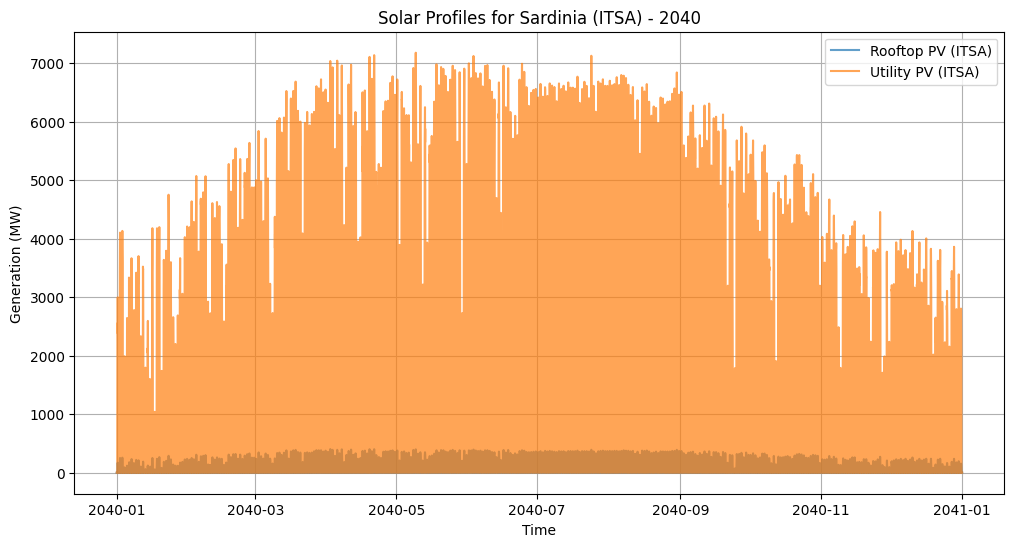

In [ ]:
import matplotlib.pyplot as plt

if 'RES_profiles' not in locals() and 'RES_profiles' not in globals():
    print("❌ Error: 'RES_profiles' is not defined. Please run the previous cells to load the data first.")
else:
    # Plot solar profiles for Sardinia (ITSA)
    plt.figure(figsize=(12, 6))
    plt.plot(RES_profiles.index, RES_profiles['ITSA_Rooftop_PV'], label='Rooftop PV (ITSA)', alpha=0.7)
    plt.plot(RES_profiles.index, RES_profiles['ITSA_Utility_PV'], label='Utility PV (ITSA)', alpha=0.7)
    plt.title('Solar Profiles for Sardinia (ITSA) - 2040')
    plt.xlabel('Time')
    plt.ylabel('Generation (MW)')
    plt.legend()
    plt.grid(True)
    plt.show()

### Wind - Offshore and Onshore

In [ ]:
# Corrected Scaling for Wind Profiles
for z in zones:
    if z in capacities and 'Wind' in capacities[z]:
        wind_data = capacities[z]['Wind']
        onshore_cap = wind_data.get('Installed capacities Onshore wind (GW):', 0.0)
        offshore_cap = wind_data.get('Installed capacities Offshore wind (GW):', 0.0)

        onshore_col = f"{z}_Wind_Onshore"
        offshore_col = f"{z}_Wind_Offshore"

        if onshore_col in RES_profiles.columns:
            RES_profiles[onshore_col] = RES_profiles[onshore_col] * onshore_cap * 1e3
        if offshore_col in RES_profiles.columns:
            RES_profiles[offshore_col] = RES_profiles[offshore_col] * offshore_cap * 1e3

print("✅ Absolute wind profiles with corrected column mapping (MW).")

✅ Absolute wind profiles with corrected column mapping (MW).


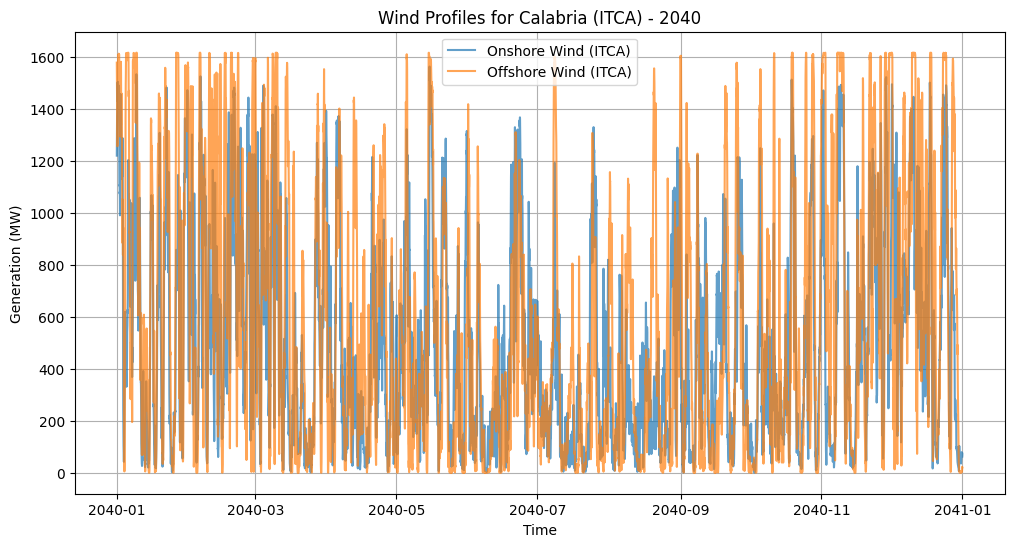

In [ ]:
import matplotlib.pyplot as plt

if 'RES_profiles' not in locals() and 'RES_profiles' not in globals():
    print("❌ Error: 'RES_profiles' is not defined. Please run the previous cells to load the data first.")
else:
    # Plot wind profiles for Calabria (ITCA)
    plt.figure(figsize=(12, 6))

    # Check if the columns exist before plotting
    if 'ITCA_Wind_Onshore' in RES_profiles.columns:
        plt.plot(RES_profiles.index, RES_profiles['ITCA_Wind_Onshore'], label='Onshore Wind (ITCA)', alpha=0.7)
    if 'ITCA_Wind_Offshore' in RES_profiles.columns:
        plt.plot(RES_profiles.index, RES_profiles['ITCA_Wind_Offshore'], label='Offshore Wind (ITCA)', alpha=0.7)

    plt.title('Wind Profiles for Calabria (ITCA) - 2040')
    plt.xlabel('Time')
    plt.ylabel('Generation (MW)')
    plt.legend()
    plt.grid(True)
    plt.show()

### Hydro - RoR, Pondage, Reservoir and Pump Storage

In [ ]:
# Define keywords for hydro components, splitting PS into Open and Closed
hydro_keywords = ['RoR', 'Pondage', 'Res_', 'PS_Open', 'PS_Closed']

# Identify columns matching the keywords
hydro_columns = [col for col in RES_profiles.columns if any(kw in col for kw in hydro_keywords)]

# Group them by type for better visibility
print("Hydro-related Columns By Category:")
for kw in hydro_keywords:
    matches = [c for c in hydro_columns if kw in c]
    if matches:
        label = kw.replace('_', ' ')
        print(f"{label} related: {matches[:3]} ... (Total: {len(matches)})")

Hydro-related Columns By Category:
RoR related: ['ITCA_RoR_MW', 'ITCN_RoR_MW', 'ITCS_RoR_MW'] ... (Total: 9)
Pondage related: ['ITCA_Pondage_MW', 'ITCN_Pondage_MW', 'ITCS_Pondage_MW'] ... (Total: 9)
Res  related: ['ITCA_Res_Inflow_MW', 'ITCA_Res_Min_Turbine_MW', 'ITCA_Res_Max_Turbine_MW'] ... (Total: 27)
PS Open related: ['ITCA_PS_Open_Inflow_MW', 'ITCN_PS_Open_Inflow_MW', 'ITCS_PS_Open_Inflow_MW'] ... (Total: 13)
PS Closed related: ['ITCA_PS_Closed_Inflow_MW', 'ITCN_PS_Closed_Inflow_MW', 'ITCS_PS_Closed_Inflow_MW'] ... (Total: 15)


In [ ]:
# hydro paramteres for zone
selected_zone = "AT00"
capacities[selected_zone]['Hydro']

{'Run of River - Total turbining capacity (MW)': 5350.125759999998,
 'Pondage - Total reservoir capacity (GWh)': 5.332957,
 'Pondage - Total turbining capacity (MW)': 1149.307,
 'Reservoir - Total reservoir capacity (GWh)': 769.0365679999999,
 'Reservoir - Total turbining capacity (MW)': 2787.128999999999,
 'Pump Storage (open loop, with natural inflows) - Total reservoir capacity (GWh)': 1962.653,
 'Pump Storage (open loop, with natural inflows) - Total turbining capacity (MW)': 8082.5,
 'Pump Storage (open loop, with natural inflows) - Total pumping capacity (MW)': -7432.919999999999,
 'Pure Pump Storage (closed loop, no natural inflows) - Total reservoir capacity (GWh)': 3.6,
 'Pure Pump Storage (closed loop, no natural inflows) - Total turbining capacity (MW)': 450.0,
 'Pure Pump Storage (closed loop, no natural inflows) - Total pumping capacity (MW)': -450.0}

### Unflexible RES Sum

In [ ]:
# Define the RES component suffixes to sum
unflex_res_components = ['Rooftop_PV', 'Utility_PV', 'Wind_Onshore', 'Wind_Offshore', 'RoR_MW', 'Other_RES']

total_res_columns = []

for z in zones:
    zone_cols = [f"{z}_{comp}" for comp in unflex_res_components if f"{z}_{comp}" in RES_profiles.columns]
    if zone_cols:
        RES_profiles[f"{z}_Nonflex_Total_RES"] = RES_profiles[zone_cols].sum(axis=1)
        total_res_columns.append(f"{z}_Nonflex_Total_RES")

# Fix: Display the columns from the DataFrame instead of calling .head() on the list
if total_res_columns:
    display(RES_profiles[total_res_columns].head(3))
else:
    print("No Nonflex_Total_RES columns were created.")

,ITCA_Nonflex_Total_RES,ITCN_Nonflex_Total_RES,ITCS_Nonflex_Total_RES,ITS1_Nonflex_Total_RES,ITN1_Nonflex_Total_RES,ITSA_Nonflex_Total_RES,ITSI_Nonflex_Total_RES,AT00_Nonflex_Total_RES,SI00_Nonflex_Total_RES
2040-01-01 00:00:00,3002.561495,3262.646478,7006.363172,11547.596945,3997.706233,4175.362576,4783.773034,4052.803001,167.813692
2040-01-01 01:00:00,3031.930702,3199.463882,6852.600197,11694.034422,3898.105945,4160.096640,4505.237300,4100.621813,166.732396
2040-01-01 02:00:00,3044.296016,3289.805503,6801.167513,11768.849289,3810.568549,4120.442617,4067.328122,3982.951088,168.309306


## 6, Gas Infrastructure Data

In [ ]:
gas_infra_path = os.path.join(INTER_DIR, f"gas_infrastructure_{year}.json")

try:
    with open(gas_infra_path, 'r') as f:
        gas_infra_dic = json.load(f)

    LNG = pd.DataFrame(gas_infra_dic['LNG'])
    Storage = pd.DataFrame(gas_infra_dic['Storage'])
    Internal_CB = pd.DataFrame(gas_infra_dic['Cross_border']['Internal'])
    Import_CB = pd.DataFrame(gas_infra_dic['Cross_border']['Import'])
    Export_CB = pd.DataFrame(gas_infra_dic['Cross_border']['Export'])

    print("Gas Infrastructure Capacities are imported: LNG, Storage, Internal_CB, Import_CB, and Export_CB.")

except FileNotFoundError:
    print(f"❌ Error: The file {os.path.basename(gas_infra_path)} was not found in {os.path.dirname(gas_infra_path)}.")
except Exception as e:
    print(f"❌ An error occurred: {e}")

Gas Infrastructure Capacities are imported: LNG, Storage, Internal_CB, Import_CB, and Export_CB.


In [ ]:
# Displaying the list of cross-border imports for gas infrastructure
print("--- Gas Infrastructure: Import Cross-Border Connections ---")
display(Import_CB)

--- Gas Infrastructure: Import Cross-Border Connections ---


,From Country,To Country,LEVEL,2040
0,Albania,Italy,LOW,325.000
1,Algeria,Italy,LOW,1154.470
2,Croatia,Slovenia,LOW,43.570
3,Czechia,Austria,LOW,0.000
4,Germany,Austria,LOW,789.056
5,Greece (IGI),Italy,LOW,0.000
6,Hungary,Austria,LOW,0.000
7,Hungary,Slovenia,LOW,0.000
8,Libya,Italy,LOW,493.740
9,Malta,Italy,LOW,0.000


## x, Additional Inputs - Not Yet Defined

In [ ]:
# Conventional electricty generators

conventional_mix_generator = {
    "AT00": {"coal": 0,   "gas_ccgt": 3500, "nuclear": 5000},
    "ITN1": {"coal": 0,   "gas_ccgt": 22000, "nuclear": 0},
    "ITCN": {"coal": 0,   "gas_ccgt": 3500,  "nuclear": 0},
    "ITCS": {"coal": 1900, "gas_ccgt": 4000,  "nuclear": 0},
    "ITS1":  {"coal":2500,   "gas_ccgt": 5500,  "nuclear": 0},
    "ITCA": {"coal": 0,   "gas_ccgt": 2800,  "nuclear": 0},
    "ITSI": {"coal": 0,   "gas_ccgt": 3200,  "nuclear": 0},
    "ITSA": {"coal": 1000, "gas_ccgt": 1200,  "nuclear": 0},
    "SI00": {"coal": 945,   "gas_ccgt": 945, "nuclear": 348}
}


In [ ]:
### Adding NTC between national nodes

italian_h2_connections = [
    ("ITSI", "ITCA"),
    ("ITCA", "ITS1"),
    ("ITS1", "ITCS"),
    ("ITCS", "ITCN"),
    ("ITCN", "ITN1")
]

new_ntc_rows = []
for z1, z2 in italian_h2_connections:
    new_ntc_rows.append({
        'zone 1': z1,
        'zone 2': z2,
        'capacity_MW': 25000.0,
        'capacity_rev_MW': 25000.0,
        'efficiency': 0.99
    })

# Append to existing NTC_H2_df
if 'NTC_H2_df' in locals():
    NTC_H2_df = pd.concat([NTC_H2_df, pd.DataFrame(new_ntc_rows)], ignore_index=True)
else:
    NTC_H2_df = pd.DataFrame(new_ntc_rows)

print("✅ Successfully added internal Italian H2 NTCs.")
display(NTC_H2_df.tail(5))

✅ Successfully added internal Italian H2 NTCs.


,zone 1,zone 2,capacity_MW,capacity_rev_MW,efficiency
1,ITSI,ITCA,25000.0,25000.0,0.99
2,ITCA,ITS1,25000.0,25000.0,0.99
3,ITS1,ITCS,25000.0,25000.0,0.99
4,ITCS,ITCN,25000.0,25000.0,0.99
5,ITCN,ITN1,25000.0,25000.0,0.99


Average Hourly Demands per Zone (MW):


type,CH4_heat,El_market,El_prosumer,H2_heat,H2_zone_1,H2_zone_2,SNG,eDiesel,eKerosine
zone,,,,,,,,,
AT00,0,8341,3828,2227,1282,4350,0,0,0
ITCA,203,397,368,176,0,0,0,0,0
ITCN,945,1847,1718,819,0,0,0,0,0
ITCS,1815,3643,3379,1571,0,0,0,0,0
ITN1,6325,11750,10931,5496,2295,9148,0,0,0
ITS1,741,1512,1392,641,0,0,0,0,0
ITSA,349,1044,318,302,0,0,0,0,0
ITSI,616,1286,1192,532,0,0,0,0,0
SI00,301,995,727,229,132,446,0,0,0


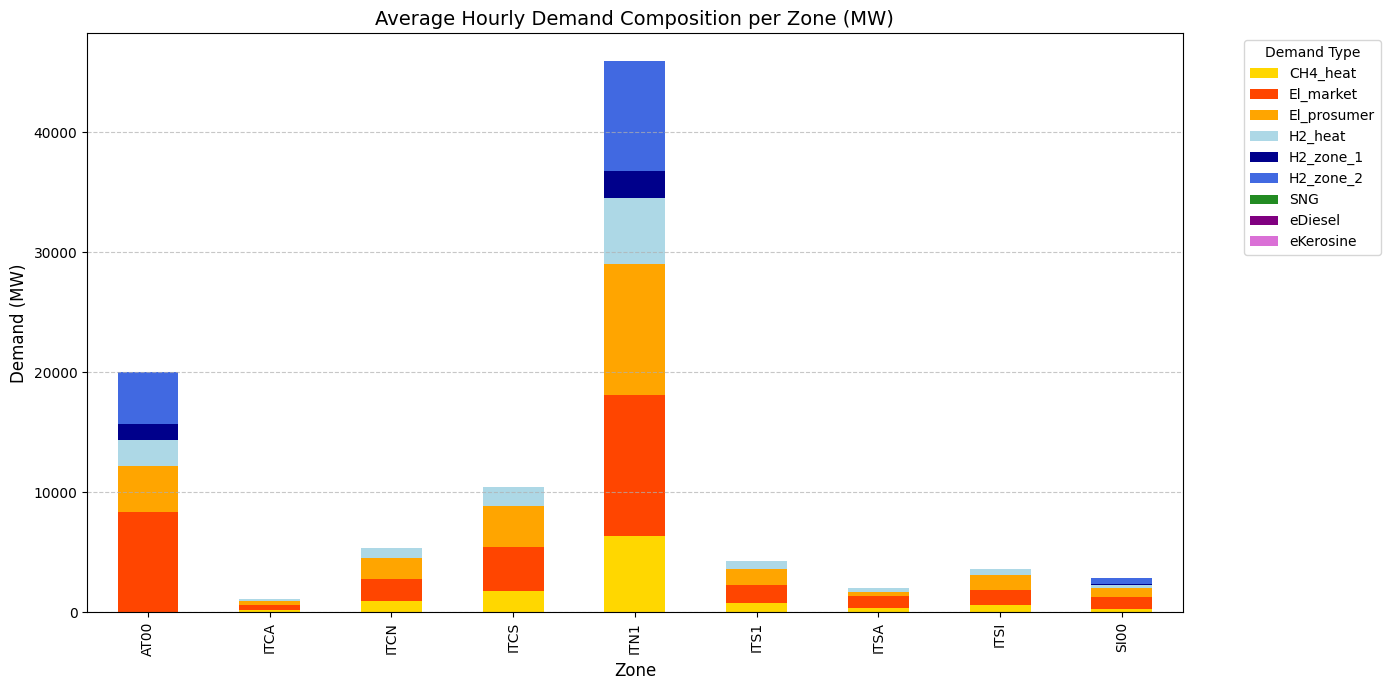

In [ ]:
# 1. Calculate the mean of all demand columns
demand_means = demand_profiles.mean()

# 2. Extract zone and demand type from the index
demand_df = demand_means.reset_index()
demand_df.columns = ['column', 'MW']
demand_df['zone'] = demand_df['column'].apply(lambda x: x.split('_')[0])
demand_df['type'] = demand_df['column'].apply(lambda x: '_'.join(x.split('_')[1:]))

# 3. Pivot the data
demand_pivot = demand_df.pivot(index='zone', columns='type', values='MW').fillna(0)
demand_pivot = demand_pivot.astype(int)

# 4. Define Color Mapping for Commodities
# Hydrogen: Blues, Gas: Yellow, Electricity: Oranges/Reds, Synfuels: Greens/Purples
color_map = {
    'CH4_heat': '#FFD700',    # Gold/Yellow
    'H2_heat': '#add8e6',     # Light Blue
    'H2_zone_1': '#00008b',   # Dark Blue
    'H2_zone_2': '#4169e1',   # Royal Blue
    'El_market': '#ff4500',   # OrangeRed
    'El_prosumer': '#ffa500', # Orange
    'SNG': '#228b22',         # Forest Green
    'eDiesel': '#800080',     # Purple
    'eKerosine': '#da70d6'    # Orchid
}

# Match colors to current pivot columns
colors = [color_map.get(col, '#333333') for col in demand_pivot.columns]

# 5. Display the table
print("Average Hourly Demands per Zone (MW):")
display(demand_pivot)

# 6. Plotting with custom colors
ax = demand_pivot.plot(kind='bar', stacked=True, figsize=(14, 7), color=colors)
plt.title("Average Hourly Demand Composition per Zone (MW)", fontsize=14)
plt.ylabel("Demand (MW)", fontsize=12)
plt.xlabel("Zone", fontsize=12)
plt.legend(title="Demand Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# adding comodities prices as input in model data
prices = {
    "commodity" : {
      "coal (EUR/t)" : 25,
      "gas (EUR/MWh)" : 40,
      "CO2 (EUR/tCO2)" : 63,
      "oil (EUR/barrel)" : 100,
      "H2 (EUR/MWh)" : 28
      },
    "technology" : {
      "nuclear (EUR/MWh)" : 12,
      "RES (EUR/MWh)" : 4.6,
      "SMR (EUR/MWh)" : 15.0
      }
}

# Model Data

In [ ]:
model_data = {
    "Global": {},
    "Regional": {},
    "Zonal": {},
    "Local": {}
}

# Initialize zonal sub-dictionaries for each project zone
for z in zones:
    model_data["Zonal"][z] = {}

# Add sublayers to Regional level
model_data["Regional"]["electricity"] = {}
model_data["Regional"]["H2"] = {}
model_data["Regional"]["CH4"] = {}


## Global level

In [ ]:
# Map to the Global segment of the hierarchical model
model_data["Global"]["prices"] = prices

print("✅ Added commodity prices to model_data['Global']:")
for commodity, price in model_data["Global"]["prices"].items():
    print(f"  - {commodity}: {price}")

✅ Added commodity prices to model_data['Global']:
  - commodity: {'coal (EUR/t)': 25, 'gas (EUR/MWh)': 40, 'CO2 (EUR/tCO2)': 63, 'oil (EUR/barrel)': 100, 'H2 (EUR/MWh)': 28}
  - technology: {'nuclear (EUR/MWh)': 12, 'RES (EUR/MWh)': 4.6, 'SMR (EUR/MWh)': 15.0}


## Regional Level

In [ ]:
# Map regional-level data

# electricity
model_data["Regional"]["electricity"]["NTC"] = NTC_elec_df

# H2
model_data["Regional"]["H2"]["NTC"] = NTC_H2_df
model_data["Regional"]["H2"]["Import"] = H2_import_df

# Natural gas - CH4
model_data["Regional"]["CH4"]["LNG"] = LNG
model_data["Regional"]["CH4"]["Storage"] = Storage
model_data["Regional"]["CH4"]["NTC"] = {
    "Internal" : Internal_CB,
    "Import" : Import_CB,
    "Export" : Export_CB
}

print("✅ Populated model_data['Regional'] with:")
print(f"  - Electricity NTCs: {len(NTC_elec_df)} connections")
print(f"  - Hydrogen NTCs: {len(NTC_H2_df)} connections")
if 'gas_infra_dic' in locals():
    print("  - CH4 Gas Infrastructure (LNG, Storage, and Cross-border capacities)")

✅ Populated model_data['Regional'] with:
  - Electricity NTCs: 20 connections
  - Hydrogen NTCs: 6 connections
  - CH4 Gas Infrastructure (LNG, Storage, and Cross-border capacities)


In [ ]:
model_data["Regional"]

{'electricity': {'NTC':    zone 1 zone 2  capacity, MW  losses
  0    AT00   ITN1         875.0    0.95
  1    ITN1   AT00         695.0    0.95
  2    AT00   SI00         950.0    0.95
  3    SI00   AT00         950.0    0.95
  4    ITCN   ITCS        4650.0    0.95
  5    ITCS   ITCN        5350.0    0.95
  6    ITCN   ITN1        4500.0    0.95
  7    ITN1   ITCN        5300.0    0.95
  8    ITCS   ITS1        3100.0    0.95
  9    ITS1   ITCS        5700.0    0.95
  10   ITCS   ITSA         720.0    0.95
  11   ITSA   ITCS         900.0    0.95
  12   ITN1   SI00        1080.0    0.95
  13   SI00   ITN1        1153.0    0.95
  14   ITS1   ITCA        2000.0    0.95
  15   ITCA   ITS1        3250.0    0.95
  16   ITSI   ITCA        2000.0    0.95
  17   ITCA   ITSI        2000.0    0.95
  18   ITCS   ITN1        2000.0    0.95
  19   ITN1   ITCS        2000.0    0.95},
 'H2': {'NTC':   zone 1 zone 2  capacity_MW  capacity_rev_MW  efficiency
  0   AT00   ITN1       5250.0           7

## Zonal Level

### Demand Profiles

In [ ]:
### ZONAL DEMAND PROFILES MAPPING ###
# This cell maps time-series from demand_profiles into the hierarchical model_data['Zonal'] structure

for z in zones:
    # Ensure the zonal container exists
    if z not in model_data['Zonal']:
        model_data['Zonal'][z] = {}

    # Identify columns belonging to this zone (e.g., 'ITCA_El_market')
    zone_cols = [col for col in demand_profiles.columns if col.startswith(f"{z}_")]

    for col in zone_cols:
        # Strip the zone prefix (e.g., 'ITCA_') to create a clean key (e.g., 'El_market')
        profile_key = col.replace(f"{z}_", "", 1)
        model_data['Zonal'][z][profile_key] = demand_profiles[col]

print(f"✅ Successfully mapped {len(demand_profiles.columns)} demand profiles across {len(zones)} zones in model_data['Zonal'].")

# Verification
example_z = zones[0]
print(f"\nClean keys for {example_z}: {list(model_data['Zonal'][example_z].keys())}")

✅ Successfully mapped 81 demand profiles across 9 zones in model_data['Zonal'].

Clean keys for ITCA: ['H2_zone_1', 'H2_zone_2', 'H2_heat', 'CH4_heat', 'El_market', 'El_prosumer', 'SNG', 'eDiesel', 'eKerosine']


### Nonflex_Total_RES

In [ ]:
# Add _Nonflex_Total_RES per zone to the model_data['Zonal'] dictionary
for z in zones:
    col_name = f"{z}_Nonflex_Total_RES"
    if col_name in RES_profiles.columns:
        # Ensure the zonal dictionary exists in the hierarchical structure
        if z not in model_data['Zonal']:
            model_data['Zonal'][z] = {}

        # Map the profile to the Zonal level
        model_data['Zonal'][z]['Nonflex_Total_RES'] = RES_profiles[col_name]
    else:
        print(f"⚠️ Warning: Column {col_name} not found in RES_profiles.")

print("✅ Successfully added Nonflex_Total_RES to model_data['Zonal'].")

# Verify the updated keys for a sample zone
sample_z = zones[0]
if sample_z in model_data['Zonal']:
    print(f"\nZonal keys in model_data['Zonal']['{sample_z}']: {list(model_data['Zonal'][sample_z].keys())}")

✅ Successfully added Nonflex_Total_RES to model_data['Zonal'].

Zonal keys in model_data['Zonal']['ITCA']: ['H2_zone_1', 'H2_zone_2', 'H2_heat', 'CH4_heat', 'El_market', 'El_prosumer', 'SNG', 'eDiesel', 'eKerosine', 'Nonflex_Total_RES']


### Pondage and Reservoir inflow profiles

In [ ]:
# Map Pondage and Reservoir inflow profiles to model_data['Zonal']
for z in zones:
    # Ensure the zonal container exists
    if z not in model_data['Zonal']:
        model_data['Zonal'][z] = {}

    zonal_tier = model_data['Zonal'][z]

    # Map Pondage MW profile
    pond_col = f"{z}_Pondage_MW"
    if pond_col in RES_profiles.columns:
        zonal_tier['Pondage_MW'] = RES_profiles[pond_col]

    # Map Reservoir Inflow MW profile
    res_inflow_col = f"{z}_Res_Inflow_MW"
    if res_inflow_col in RES_profiles.columns:
        zonal_tier['Res_Inflow_MW'] = RES_profiles[res_inflow_col]

print("✅ Successfully added Pondage and Reservoir inflow profiles to model_data['Zonal'] for all zones.")

# Verification
first_zone = zones[0]
print(f"\nUpdated keys in model_data['Zonal']['{first_zone}']:", [k for k in model_data['Zonal'][first_zone].keys() if 'MW' in k])

✅ Successfully added Pondage and Reservoir inflow profiles to model_data['Zonal'] for all zones.

Updated keys in model_data['Zonal']['ITCA']: ['Pondage_MW', 'Res_Inflow_MW']


### Electrolysers - SRES and DRES

In [ ]:
# Define the share parameter
share = input_data['share']

for z in zones:
    # Ensure the zonal dictionary exists in model_data
    if z not in model_data['Zonal']:
        model_data['Zonal'][z] = {}

    # Reference the specific zonal tier for this zone
    zonal_tier = model_data['Zonal'][z]

    # 1. Add the share parameter and calculate SRES/DRES profiles
    zonal_tier['share'] = share

    if 'Nonflex_Total_RES' in zonal_tier:
        nonflex_res = zonal_tier['Nonflex_Total_RES']
        zonal_tier['SRES'] = nonflex_res * share
        zonal_tier['DRES'] = nonflex_res * (1 - share)
    else:
        print(f"⚠️ Warning: 'Nonflex_Total_RES' not found for zone {z} in model_data['Zonal'].")

    # 2. Extract Electrolyser Capacities and Efficiencies from the source capacities dictionary
    if z in capacities and 'Electrolyser' in capacities[z]:
        ely_data = capacities[z]['Electrolyser']

        # Extract electrical capacity
        total_ely_cap = ely_data.get('Net maximum capacity \n(MW)', 0.0)
        zonal_tier['SRES_electrolyser'] = total_ely_cap * share
        zonal_tier['DRES_electrolyser'] = total_ely_cap * (1 - share)

        # Extract/Default Efficiency
        eff = ely_data.get('Average efficiency', 0.68)
        if eff <= 0:
            print(f"ℹ️ Adjusted efficiency for {z} electrolyser from {eff} to 0.68")
            eff = 0.68

        zonal_tier['elec_efficiency'] = eff
    else:
        print(f"⚠️ Warning: Electrolyser data not found for zone {z} in raw capacities dictionary.")

print("✅ Successfully updated model_data['Zonal'] with shares, SRES/DRES profiles, and electrolyzer parameters.")

# Verification of a sample zone
sample_z = zones[0]
print(f"\nSample keys in model_data['Zonal']['{sample_z}']: {list(model_data['Zonal'][sample_z].keys())}")

ℹ️ Adjusted efficiency for SI00 electrolyser from 0 to 0.68
✅ Successfully updated model_data['Zonal'] with shares, SRES/DRES profiles, and electrolyzer parameters.

Sample keys in model_data['Zonal']['ITCA']: ['H2_zone_1', 'H2_zone_2', 'H2_heat', 'CH4_heat', 'El_market', 'El_prosumer', 'SNG', 'eDiesel', 'eKerosine', 'Nonflex_Total_RES', 'Pondage_MW', 'Res_Inflow_MW', 'share', 'SRES', 'DRES', 'SRES_electrolyser', 'DRES_electrolyser', 'elec_efficiency']


### SMR

In [ ]:
# Update SMR capacities in model_data using smr_capacities DataFrame
# If a country has multiple zones, divide the total capacity equally among them

# 1. Count zones per country prefix
from collections import Counter
country_counts = Counter(z[:2] for z in zones)

for zone in zones:
    country_code = zone[:2]
    num_zones = country_counts[country_code]

    # Initialize with 0 in the Zonal tier to ensure keys exist
    if zone not in model_data['Zonal']:
        model_data['Zonal'][zone] = {}

    model_data['Zonal'][zone]['SMR_g_zone1'] = 0.0
    model_data['Zonal'][zone]['SMR_b_zone1'] = 0.0

    if country_code in smr_capacities.index:
        row = smr_capacities.loc[country_code]
        # Divide total capacity by the number of zones in that country
        capacity_per_zone = row['CAPACITY [MW]'] / num_zones
        ccs_enabled = row['CCS']

        if ccs_enabled:
            # If CCS is True, it's Blue SMR
            model_data['Zonal'][zone]['SMR_b_zone1'] = capacity_per_zone
        else:
            # If CCS is False, it's Grey SMR
            model_data['Zonal'][zone]['SMR_g_zone1'] = capacity_per_zone

print(f"✅ Successfully extended model_data['Zonal'] with SMR capacities (split across {len(zones)} zones).")

# Verification: Display the split entries
smr_summary = {z: {'Grey': model_data['Zonal'][z]['SMR_g_zone1'], 'Blue': model_data['Zonal'][z]['SMR_b_zone1']} for z in zones}
display(pd.DataFrame(smr_summary).T.round(2))

✅ Successfully extended model_data['Zonal'] with SMR capacities (split across 9 zones).


,Grey,Blue
ITCA,0.00,383.57
ITCN,0.00,383.57
ITCS,0.00,383.57
ITS1,0.00,383.57
ITN1,0.00,383.57
ITSA,0.00,383.57
ITSI,0.00,383.57
AT00,423.35,0.00
SI00,0.00,0.00


### H2 storage

In [ ]:
# Map H2 Storage capacities (Energy and Power) to model_data['Zonal']
# Units in data: Energy in GWh (converted to MWh), Power in MW

for zone in zones:
    country_code = zone[:2]

    # Ensure the zonal container exists
    if zone not in model_data['Zonal']:
        model_data['Zonal'][zone] = {}

    zonal_tier = model_data['Zonal'][zone]

    # Initialize values in the Zonal tier
    zonal_tier['H2_storage_energy_z1'] = 0.0
    zonal_tier['H2_storage_energy_z2'] = 0.0
    zonal_tier['H2_storage_p_max_z1'] = 0.0
    zonal_tier['H2_storage_p_max_z2'] = 0.0
    zonal_tier['H2_storage_p_load_z1'] = 0.0
    zonal_tier['H2_storage_p_load_z2'] = 0.0

    # Filter h2_storage for the specific country
    country_data = h2_storage[h2_storage['NODE'] == country_code]

    # Map Zone 1 (Distributed/Tank)
    z1_mask = country_data['H2 ZONE'] == 'ZONE 1'
    if z1_mask.any():
        z1_row = country_data[z1_mask].iloc[0]
        e_val = z1_row['CAPACITY [GWh]']
        p_max = z1_row.get('MAX POWER [MW]', 0.0)
        p_load = z1_row.get('MAX LOAD [MW]', 0.0)

        if country_code == 'IT':
            zonal_tier['H2_storage_energy_z1'] = (e_val * 1e3) / 7
            zonal_tier['H2_storage_p_max_z1'] = p_max / 7
            zonal_tier['H2_storage_p_load_z1'] = p_load / 7
        else:
            zonal_tier['H2_storage_energy_z1'] = e_val * 1e3
            zonal_tier['H2_storage_p_max_z1'] = p_max
            zonal_tier['H2_storage_p_load_z1'] = p_load

    # Map Zone 2 (Caverns/Large scale)
    z2_mask = country_data['H2 ZONE'] == 'ZONE 2'
    if z2_mask.any():
        z2_row = country_data[z2_mask].iloc[0]
        e_val = z2_row['CAPACITY [GWh]']
        p_max = z2_row.get('MAX POWER [MW]', 0.0)
        p_load = z2_row.get('MAX LOAD [MW]', 0.0)

        if country_code == 'IT':
            zonal_tier['H2_storage_energy_z2'] = (e_val * 1e3) / 7
            zonal_tier['H2_storage_p_max_z2'] = p_max / 7
            zonal_tier['H2_storage_p_load_z2'] = p_load / 7
        else:
            zonal_tier['H2_storage_energy_z2'] = e_val * 1e3
            zonal_tier['H2_storage_p_max_z2'] = p_max
            zonal_tier['H2_storage_p_load_z2'] = p_load

print('✅ Successfully added H2 storage energy and power capacities to model_data[\'Zonal\'].')

# Verification for a sample zone
sample_z = 'ITN1'
if sample_z in model_data['Zonal']:
    z_info = model_data['Zonal'][sample_z]
    print(f'\n{sample_z} Storage Z1 -> Energy: {z_info.get("H2_storage_energy_z1", 0):.2f} MWh, P_max: {z_info.get("H2_storage_p_max_z1", 0):.2f} MW')

✅ Successfully added H2 storage energy and power capacities to model_data['Zonal'].

ITN1 Storage Z1 -> Energy: 5047.12 MWh, P_max: 210.30 MW


In [ ]:
import pandas as pd

# Improved summary of H2 storage data from the Zonal tier
h2_storage_summary = []

for zone in zones:
    z_data = model_data['Zonal'].get(zone, {})
    h2_storage_summary.append({
        'Zone': zone,
        'Z1 Energy [MWh]': z_data.get('H2_storage_energy_z1', 0),
        'Z1 P_max (Discharge) [MW]': z_data.get('H2_storage_p_max_z1', 0),
        'Z1 P_load (Charge) [MW]': z_data.get('H2_storage_p_load_z1', 0),
        'Z2 Energy [MWh]': z_data.get('H2_storage_energy_z2', 0),
        'Z2 P_max (Discharge) [MW]': z_data.get('H2_storage_p_max_z2', 0),
        'Z2 P_load (Charge) [MW]': z_data.get('H2_storage_p_load_z2', 0)
    })

# Create and display the formatted DataFrame
df_h2_storage_summary = pd.DataFrame(h2_storage_summary).set_index('Zone')

print("--- Hydrogen Storage Parameters (Zonal Tier) ---")
display(df_h2_storage_summary.round(2))

--- Hydrogen Storage Parameters (Zonal Tier) ---


,Z1 Energy [MWh],Z1 P_max (Discharge) [MW],Z1 P_load (Charge) [MW],Z2 Energy [MWh],Z2 P_max (Discharge) [MW],Z2 P_load (Charge) [MW]
Zone,,,,,,
ITCA,5047.12,210.30,210.30,740000.0,286.43,457.72
ITCN,5047.12,210.30,210.30,740000.0,286.43,457.72
ITCS,5047.12,210.30,210.30,740000.0,286.43,457.72
ITS1,5047.12,210.30,210.30,740000.0,286.43,457.72
ITN1,5047.12,210.30,210.30,740000.0,286.43,457.72
ITSA,5047.12,210.30,210.30,740000.0,286.43,457.72
ITSI,5047.12,210.30,210.30,740000.0,286.43,457.72
AT00,8630.25,359.59,359.59,0.0,0.00,0.00
SI00,1566.05,65.25,65.25,0.0,0.00,0.00


### Hydro and Battery Capacities

In [ ]:
import pandas as pd

# Integrate Hydro and Battery capacities from the capacities dictionary into model_data['Zonal']
for zone in zones:
    if zone in capacities:
        z_caps = capacities[zone]

        # Ensure the zonal container exists
        if zone not in model_data['Zonal']:
            model_data['Zonal'][zone] = {}

        zonal_tier = model_data['Zonal'][zone]

        # 1. Hydro Capacities
        if 'Hydro' in z_caps:
            h = z_caps['Hydro']
            # Reservoir
            zonal_tier['Reservoir_P_nom'] = h.get('Reservoir - Total turbining capacity (MW)', 0)
            zonal_tier['Reservoir_E_nom'] = h.get('Reservoir - Total reservoir capacity (GWh)', 0) * 1e3 # GWh to MWh

            # Pondage
            zonal_tier['Pondage_P_nom'] = h.get('Pondage - Total turbining capacity (MW)', 0)
            zonal_tier['Pondage_E_nom'] = h.get('Pondage - Total reservoir capacity (GWh)', 0) * 1e3 # GWh to MWh

            # Pump Storage Open
            zonal_tier['PHS_Open_P_nom'] = h.get('Pump Storage (open loop, with natural inflows) - Total turbining capacity (MW)', 0)
            zonal_tier['PHS_Open_P_store'] = abs(h.get('Pump Storage (open loop, with natural inflows) - Total pumping capacity (MW)', 0))
            zonal_tier['PHS_Open_E_nom'] = h.get('Pump Storage (open loop, with natural inflows) - Total reservoir capacity (GWh)', 0) * 1e3

            # Pump Storage Closed
            zonal_tier['PHS_Closed_P_nom'] = h.get('Pure Pump Storage (closed loop, no natural inflows) - Total turbining capacity (MW)', 0)
            zonal_tier['PHS_Closed_P_store'] = abs(h.get('Pure Pump Storage (closed loop, no natural inflows) - Total pumping capacity (MW)', 0))
            zonal_tier['PHS_Closed_E_nom'] = h.get('Pure Pump Storage (closed loop, no natural inflows) - Total reservoir capacity (GWh)', 0) * 1e3

        # 2. Battery Capacities
        if 'Battery' in z_caps:
            b = z_caps['Battery']
            zonal_tier['Battery_P_nom'] = b.get('Net maximum capacity - generation perspective \n(MW)', 0)
            zonal_tier['Battery_E_nom'] = b.get('Storage capacity \n(MWh)', 0)

print(f"✅ Successfully incorporated Hydro and Battery capacities into model_data['Zonal'] for {len(zones)} zones.")

# Quick verification check for a sample zone
sample = 'AT00'
print(f"\nSample Check ({sample}):")
print(f"- Battery P_nom: {model_data['Zonal'][sample].get('Battery_P_nom', 0)} MW")
print(f"- Pondage P_nom: {model_data['Zonal'][sample].get('Pondage_P_nom', 0)} MW")

✅ Successfully incorporated Hydro and Battery capacities into model_data['Zonal'] for 9 zones.

Sample Check (AT00):
- Battery P_nom: 238.6954961521824 MW
- Pondage P_nom: 1149.307 MW


### Conventional Generators

In [ ]:
# Add Coal, Gas_CCGT, and Nuclear values to model_data['Zonal']
for zone in zones:
    # Ensure the zonal dictionary exists
    if zone not in model_data['Zonal']:
        model_data['Zonal'][zone] = {}

    if zone in conventional_mix_generator:
        mix = conventional_mix_generator[zone]
        model_data['Zonal'][zone]['coal'] = mix.get('coal', 0)
        model_data['Zonal'][zone]['gas_ccgt'] = mix.get('gas_ccgt', 0)
        model_data['Zonal'][zone]['nuclear'] = mix.get('nuclear', 0)
    else:
        print(f"⚠️ Warning: No data found for zone {zone} in conventional_mix_generator.")

print("\n✅ Successfully updated model_data['Zonal'] with conventional generation electricity powers.")


✅ Successfully updated model_data['Zonal'] with conventional generation electricity powers.


### Graphical Presentation

Average Hourly Generation Potential/Capacity per Zone (MW):


,SRES,COAL,NUCLEAR,CCGT,DRES
zone,,,,,
ITCA,1218,0,0,2800,1218
ITCN,1464,0,0,3500,1464
ITCS,3341,1900,0,4000,3341
ITS1,4068,2500,0,5500,4068
ITN1,4132,0,0,22000,4132
ITSA,1741,1000,0,1200,1741
ITSI,2492,0,0,3200,2492
AT00,6380,0,5000,3500,6380
SI00,444,945,348,945,444


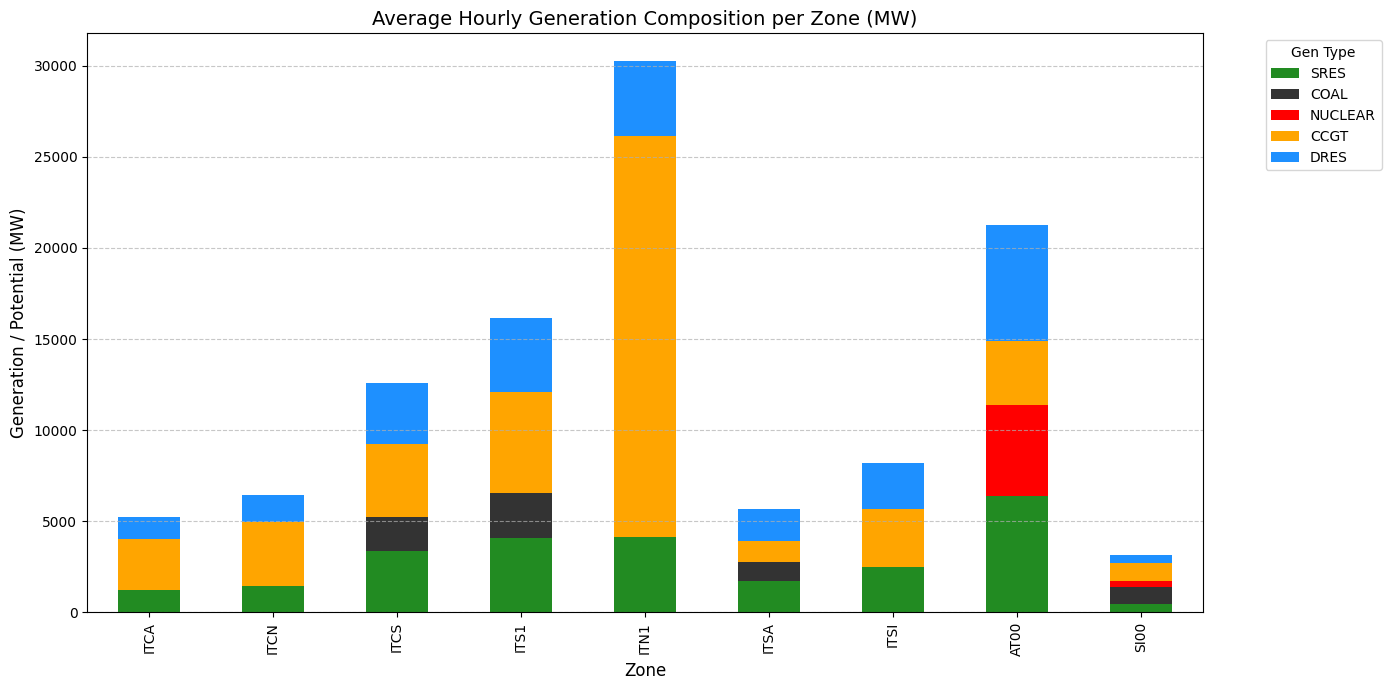

In [ ]:
# 1. Prepare the generation data using model_data
gen_stats = []

for z in zones:
    # Get conventional capacities from the updated dictionary
    mix = conventional_mix_generator.get(z, {})

    # Access the zonal tier specifically as defined in the data hierarchy
    z_tier = model_data.get('Zonal', {}).get(z, {})

    # Function to safely get mean from Series or scalar
    def get_mean(data_dict, key):
        val = data_dict.get(key, 0)
        if isinstance(val, pd.Series):
            return val.mean()
        try:
            return float(val)
        except (ValueError, TypeError):
            return 0.0

    # Calculate values from the Zonal tier
    sres_val = get_mean(z_tier, 'SRES')
    dres_val = get_mean(z_tier, 'DRES')

    gen_stats.append({
        'zone': z,
        'SRES': int(sres_val),
        'COAL': int(mix.get('coal', 0)),
        'NUCLEAR': int(mix.get('nuclear', 0)),
        'CCGT': int(mix.get('gas_ccgt', 0)),
        'DRES': int(dres_val)
    })

gen_df = pd.DataFrame(gen_stats).set_index('zone').fillna(0)

# 2. Display the table
print("Average Hourly Generation Potential/Capacity per Zone (MW):")
display(gen_df)

# 3. Define Color Mapping
gen_colors = {
    'SRES': '#228b22',    # Forest Green
    'COAL': '#333333',    # Dark Grey
    'NUCLEAR': '#ff0000', # Red
    'CCGT': '#ffa500',    # Orange
    'DRES': '#1e90ff'     # Dodger Blue
}

colors = [gen_colors[col] for col in gen_df.columns]

# 4. Plotting
ax = gen_df.plot(kind='bar', stacked=True, figsize=(14, 7), color=colors)
plt.title("Average Hourly Generation Composition per Zone (MW)", fontsize=14)
plt.ylabel("Generation / Potential (MW)", fontsize=12)
plt.xlabel("Zone", fontsize=12)
plt.legend(title="Gen Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Select the first zone for the example from the Zonal tier
example_zone = list(model_data['Zonal'].keys())[0]
z_data = model_data['Zonal'][example_zone]

profiles = []
scalars = []

for key, value in z_data.items():
    if isinstance(value, pd.Series):
        profiles.append(key)
    else:
        scalars.append(key)

print(f"--- Data stored for Zone: {example_zone} in model_data['Zonal'] ---")

print("\n[Time-Series Profiles]")
for p in sorted(profiles):
    print(f"  - {p}")

print("\n[Scalar Parameters / Capacities]")
for s in sorted(scalars):
    val = z_data[s]
    # Handle potentially long output for nested dicts if any exist
    print(f"  - {s}: {val}")

--- Data stored for Zone: ITCA in model_data['Zonal'] ---

[Time-Series Profiles]
  - CH4_heat
  - DRES
  - El_market
  - El_prosumer
  - H2_heat
  - H2_zone_1
  - H2_zone_2
  - Nonflex_Total_RES
  - Pondage_MW
  - Res_Inflow_MW
  - SNG
  - SRES
  - eDiesel
  - eKerosine

[Scalar Parameters / Capacities]
  - Battery_E_nom: 14264
  - Battery_P_nom: 1863
  - DRES_electrolyser: 477.6
  - H2_storage_energy_z1: 5047.12
  - H2_storage_energy_z2: 740000.0
  - H2_storage_p_load_z1: 210.29657142857144
  - H2_storage_p_load_z2: 457.7198035714286
  - H2_storage_p_max_z1: 210.29657142857144
  - H2_storage_p_max_z2: 286.4306071428571
  - PHS_Closed_E_nom: 0.0
  - PHS_Closed_P_nom: 0.0
  - PHS_Closed_P_store: 0.0
  - PHS_Open_E_nom: 0.0
  - PHS_Open_P_nom: 0.0
  - PHS_Open_P_store: 0.0
  - Pondage_E_nom: 0.0
  - Pondage_P_nom: 0.0
  - Reservoir_E_nom: 572400.0
  - Reservoir_P_nom: 701.2840000000001
  - SMR_b_zone1: 383.56857142857143
  - SMR_g_zone1: 0.0
  - SRES_electrolyser: 477.6
  - coal: 0
  - 

In [ ]:
model_data["Regional"]["electricity"]["NTC"]

,zone 1,zone 2,"capacity, MW",losses
0,AT00,ITN1,875.0,0.95
1,ITN1,AT00,695.0,0.95
2,AT00,SI00,950.0,0.95
3,SI00,AT00,950.0,0.95
4,ITCN,ITCS,4650.0,0.95
5,ITCS,ITCN,5350.0,0.95
6,ITCN,ITN1,4500.0,0.95
7,ITN1,ITCN,5300.0,0.95
8,ITCS,ITS1,3100.0,0.95
9,ITS1,ITCS,5700.0,0.95


## Saving Model Data and Input data

In [ ]:
import os
import json
import pandas as pd
import numpy as np

# Define the directory for model data
MODEL_DATA_DIR = os.path.join(PROJECT_DIR, str(input_data['data_set']), 'model_data')

# Create the directory if it doesn't exist
if not os.path.exists(MODEL_DATA_DIR):
    os.makedirs(MODEL_DATA_DIR)
    print(f'Created directory: {MODEL_DATA_DIR}')

# Helper to handle pandas objects
def pd_encoder(obj):
    if isinstance(obj, pd.Series):
        return {str(k): v for k, v in obj.to_dict().items()}
    if isinstance(obj, pd.DataFrame):
        return obj.to_dict(orient='records')
    if isinstance(obj, (pd.Timestamp, np.datetime64)):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return str(obj)

def stringify_keys(d):
    """Recursively convert dictionary keys to strings to ensure JSON compatibility."""
    if isinstance(d, dict):
        return {str(k): stringify_keys(v) for k, v in d.items()}
    elif isinstance(d, list):
        return [stringify_keys(i) for i in d]
    return d

model_data_file_path = os.path.join(MODEL_DATA_DIR, 'model_data.json')

try:
    # We first stringify keys to avoid the Timestamp key error
    clean_data = stringify_keys(model_data)
    with open(model_data_file_path, 'w') as f:
        json.dump(clean_data, f, default=pd_encoder)
    print(f'✅ Successfully saved consolidated model_data to: {model_data_file_path}')
except Exception as e:
    print(f'❌ Failed to save consolidated model_data: {e}')

✅ Successfully saved consolidated model_data to: /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/2024/model_data/model_data.json


In [ ]:
print("--- Top Level Layers ---")
print(model_data.keys())

print("\n--- Global Layer Keys ---")
print(model_data['Global'].keys())

print("\n--- Regional Layer Keys ---")
print(model_data['Regional'].keys())

print("\n--- Zonal Layer (Zones) ---")
print(list(model_data['Zonal'].keys()))

# Inspect a sample zone's internal structure
sample_z = zones[0]
print(f"\n--- Sample Zonal Keys ({sample_z}) ---")
print(list(model_data['Zonal'][sample_z].keys()))

--- Top Level Layers ---
dict_keys(['Global', 'Regional', 'Zonal', 'Local'])

--- Global Layer Keys ---
dict_keys(['prices'])

--- Regional Layer Keys ---
dict_keys(['electricity', 'H2', 'CH4'])

--- Zonal Layer (Zones) ---
['ITCA', 'ITCN', 'ITCS', 'ITS1', 'ITN1', 'ITSA', 'ITSI', 'AT00', 'SI00']

--- Sample Zonal Keys (ITCA) ---
['H2_zone_1', 'H2_zone_2', 'H2_heat', 'CH4_heat', 'El_market', 'El_prosumer', 'SNG', 'eDiesel', 'eKerosine', 'Nonflex_Total_RES', 'Pondage_MW', 'Res_Inflow_MW', 'share', 'SRES', 'DRES', 'SRES_electrolyser', 'DRES_electrolyser', 'elec_efficiency', 'SMR_g_zone1', 'SMR_b_zone1', 'H2_storage_energy_z1', 'H2_storage_energy_z2', 'H2_storage_p_max_z1', 'H2_storage_p_max_z2', 'H2_storage_p_load_z1', 'H2_storage_p_load_z2', 'Reservoir_P_nom', 'Reservoir_E_nom', 'Pondage_P_nom', 'Pondage_E_nom', 'PHS_Open_P_nom', 'PHS_Open_P_store', 'PHS_Open_E_nom', 'PHS_Closed_P_nom', 'PHS_Closed_P_store', 'PHS_Closed_E_nom', 'Battery_P_nom', 'Battery_E_nom', 'coal', 'gas_ccgt', 'nucle

In [ ]:
# saving input_data
# Define the file path for input_data
input_data_json_path = os.path.join(MODEL_DATA_DIR, 'input_data.json')

# Helper function to handle non-serializable objects (Series, Timestamps, etc.)
def input_data_encoder(obj):
    if isinstance(obj, pd.Series):
        return obj.to_dict()
    if isinstance(obj, (pd.Timestamp, np.datetime64)):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return str(obj)

try:
    with open(input_data_json_path, 'w') as f:
        json.dump(input_data, f, indent=4, default=input_data_encoder)
    print(f"✅ Successfully saved input_data to: {input_data_json_path}")
except Exception as e:
    print(f"❌ Failed to save input_data JSON: {e}")

✅ Successfully saved input_data to: /content/drive/MyDrive/Colab_Notebooks/ENNOH/Zonal_model/2024/model_data/input_data.json


# Dual Network Model

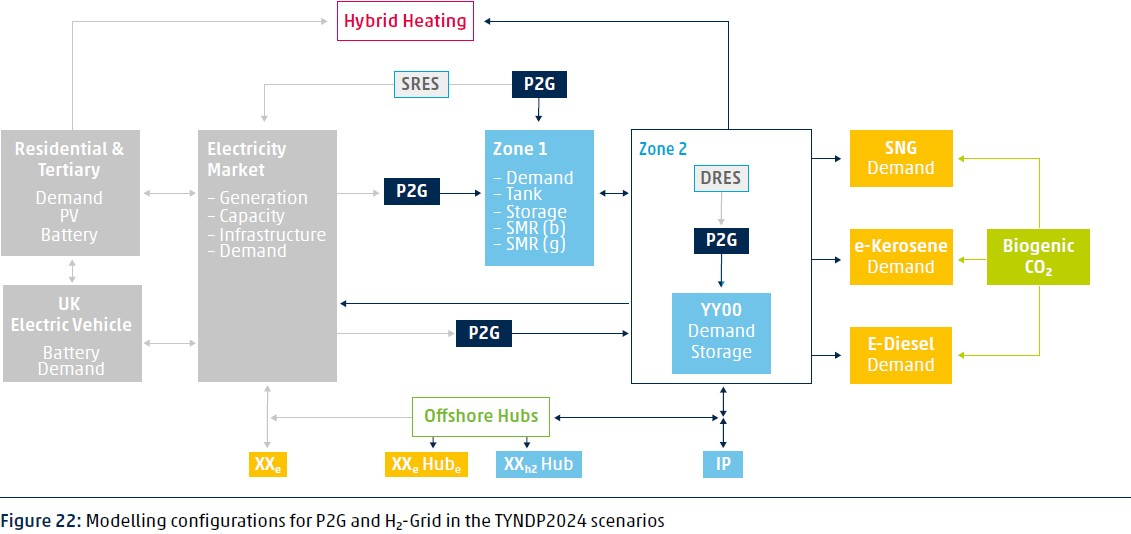

In [ ]:
warnings.simplefilter(action='ignore', category=FutureWarning)

# 1. INITIALIZE NETWORK
n_dual = pypsa.Network()

# Use profile index from the first zone in the Zonal layer to set snapshots
zones_in_model = list(model_data['Zonal'].keys())
first_zone_id = zones_in_model[0]
snapshot_index = model_data['Zonal'][first_zone_id]['Nonflex_Total_RES'].index
n_dual.set_snapshots(snapshot_index)

# Add Energy Carriers
carriers = ["AC", "H2", "natural_gas", "CO2", "SNG", "e-Kerosene", "e-Diesel",
            "coal", "hydro", "battery", "nuclear"]
for c in carriers:
    n_dual.add("Carrier", c)

prices = model_data["Global"]["prices"]

# Global market for coal
n_dual.add("Bus", "coal_market", carrier="coal")
n_dual.add("Generator", "Global_Coal_Import", bus="coal_market", carrier = "coal", p_nom_extendable=True, marginal_cost=prices["commodity"]["coal (EUR/t)"])

# 2. BUILD FULLY INTEGRATED ZONAL NETWORKS
for zone, z_data in model_data["Zonal"].items():

    # --- BUSES ---
    elec_bus = f"{zone}_electricity_market"
    n_dual.add("Bus", elec_bus, carrier="AC")
    n_dual.add("Bus", f"{zone}_gas_bus", carrier="natural_gas")

    if input_data.get('H2', False):
        n_dual.add("Bus", f"{zone}_SRES_AC", carrier="AC")
        n_dual.add("Bus", f"{zone}_DRES_AC", carrier="AC")
        n_dual.add("Bus", f"{zone}_h2_zone1", carrier="H2")
        n_dual.add("Bus", f"{zone}_h2_zone2", carrier="H2")
        if input_data.get('Synthetic_fuels', False):
          n_dual.add("Bus", f"{zone}_bio_co2", carrier="CO2")
          n_dual.add("Bus", f"{zone}_sng_bus", carrier="SNG")
          n_dual.add("Bus", f"{zone}_ekerosene_bus", carrier="e-Kerosene")
          n_dual.add("Bus", f"{zone}_ediesel_bus", carrier="e-Diesel")

    # --- GAS source ---
    n_dual.add("Generator", f"{zone}_Gas_Source", bus=f"{zone}_gas_bus", carrier="natural_gas", p_nom_extendable=True, marginal_cost=prices["commodity"]['gas (EUR/MWh)'])

    # --- E L E C T R I C I T Y   M O D E L ---
    # --- Conventional electricity generators ---
    if z_data.get('gas_ccgt', 0) > 0:
        n_dual.add("Link", f"{zone}_CCGT_Plant", bus0=f"{zone}_gas_bus", bus1=elec_bus, p_nom=z_data['gas_ccgt'], efficiency=0.55)

    if z_data.get('coal', 0) > 0:
        n_dual.add("Link", f"{zone}_Coal_Plant", bus0="coal_market", bus1=elec_bus, p_nom=z_data['coal'], efficiency=0.40, ramp_limit_up=1/12, ramp_limit_down=1/12)

    if z_data.get('nuclear', 0) > 0:
        n_dual.add("Generator", f"{zone}_Nuclear_Plant", bus=elec_bus, carrier="nuclear", p_nom=z_data['nuclear'], marginal_cost=prices["technology"]['nuclear (EUR/MWh)'], ramp_limit_up=1/48, ramp_limit_down=1/48)

    # --- Storage Assets (Replaced 'capacities' with 'z_data' from model_data['Zonal']) ---
    if input_data.get('FLEX', False):
        # 1. Hydro Reservoir
        p_res = z_data.get('Reservoir_P_nom', 0)
        if p_res > 0:
            res_inflow = z_data.get('Res_Inflow_MW', 0)
            n_dual.add("StorageUnit", f"{zone}_HPP_Reservoir", bus=elec_bus, carrier="hydro", p_nom=p_res,
                  max_hours=z_data.get('Reservoir_E_nom', 0) / p_res,
                  cyclic_state_of_charge=True, efficiency_dispatch=0.90,
                  p_max_pu=res_inflow/p_res if isinstance(res_inflow, pd.Series) else 0)

        # 2. Hydro Pondage
        p_pond = z_data.get('Pondage_P_nom', 0)
        if p_pond > 0:
            pond_inflow = z_data.get('Pondage_MW', 0)
            n_dual.add("StorageUnit", f"{zone}_HPP_Pondage", bus=elec_bus, carrier="hydro", p_nom=p_pond,
                  max_hours=z_data.get('Pondage_E_nom', 0) / p_pond,
                  cyclic_state_of_charge=True, efficiency_dispatch=0.90,
                  p_max_pu=pond_inflow/p_pond if isinstance(pond_inflow, pd.Series) else 0)

        # 3. PHS Open
        p_open = z_data.get('PHS_Open_P_nom', 0)
        if p_open > 0:
            p_pump = z_data.get('PHS_Open_P_store', 0)
            n_dual.add("StorageUnit", f"{zone}_PHS_Open", bus=elec_bus, carrier="hydro", p_nom=p_open,
                  p_max_pu_store=p_pump/p_open,
                  max_hours=z_data.get('PHS_Open_E_nom', 0) / p_open,
                  cyclic_state_of_charge=True, efficiency_dispatch=0.90, efficiency_store=0.90)

        # 4. PHS Closed
        p_closed = z_data.get('PHS_Closed_P_nom', 0)
        if p_closed > 0:
            p_pump_c = z_data.get('PHS_Closed_P_store', 0)
            n_dual.add("StorageUnit", f"{zone}_PHS_Closed", bus=elec_bus, carrier="hydro", p_nom=p_closed,
                  p_max_pu_store=p_pump_c/p_closed,
                  max_hours=z_data.get('PHS_Closed_E_nom', 0) / p_closed,
                  cyclic_state_of_charge=True, efficiency_dispatch=0.90, efficiency_store=0.90)

        # 5. Battery
        p_bat = z_data.get('Battery_P_nom', 0)
        if p_bat > 0:
            n_dual.add("StorageUnit", f"{zone}_Battery", bus=elec_bus, carrier="battery", p_nom=p_bat,
                  p_max_pu_store=1.0, # Assumed symmetrical for power input-output from Battery_P_nom logic
                  max_hours=z_data.get('Battery_E_nom', 0) / p_bat,
                  cyclic_state_of_charge=True, efficiency_dispatch=0.95, efficiency_store=0.95)



    # --- Electricity loads ---
    n_dual.add("Load", f"{zone}_elec_demand", bus=elec_bus, p_set=z_data['El_market'])

    # --- H Y D R O G E N   M O D E L ---
    if input_data.get('H2', False):
        if z_data.get('SMR_g_zone1', 0) > 0:
            n_dual.add("Link", f"{zone}_SMR_Grey", bus0=f"{zone}_gas_bus", bus1=f"{zone}_h2_zone1", p_nom=z_data['SMR_g_zone1'], efficiency=0.70, marginal_cost=prices["technology"]["SMR (EUR/MWh)"])
        if z_data.get('SMR_b_zone1', 0) > 0:
            n_dual.add("Link", f"{zone}_SMR_Blue", bus0=f"{zone}_gas_bus", bus1=f"{zone}_h2_zone1", p_nom=z_data['SMR_b_zone1'], efficiency=0.65, marginal_cost=prices["technology"]["SMR (EUR/MWh)"])

        if 'SRES' in z_data:
            n_dual.add("Generator", f"{zone}_SRES_plant", bus=f"{zone}_SRES_AC", carrier="AC", p_nom=1, p_max_pu=z_data['SRES'], marginal_cost=prices["technology"]["RES (EUR/MWh)"])
            n_dual.add("Link", f"{zone}_SRES_to_mgrid", bus0=f"{zone}_SRES_AC", bus1=elec_bus, p_nom=1e6, efficiency=1.0)
            n_dual.add("Link", f"{zone}_mgrid_to_SRES", bus0=elec_bus, bus1=f"{zone}_SRES_AC", p_nom=1e6, efficiency=1.0)

        if 'DRES' in z_data:
            n_dual.add("Generator", f"{zone}_DRES_plant", bus=f"{zone}_DRES_AC", carrier="AC", p_nom=1, p_max_pu=z_data['DRES'], marginal_cost=prices["technology"]["RES (EUR/MWh)"])
            n_dual.add("Link", f"{zone}_mgrid_to_DRES", bus0=elec_bus, bus1=f"{zone}_DRES_AC", p_nom=1e6, efficiency=1.0)

        if z_data.get('SRES_electrolyser', 0) > 0:
            n_dual.add("Link", f"{zone}_SRES_Electrolyser", bus0=f"{zone}_SRES_AC", bus1=f"{zone}_h2_zone1",
                       p_nom=z_data['SRES_electrolyser'], efficiency=z_data.get('elec_efficiency', 0.68))
        if z_data.get('DRES_electrolyser', 0) > 0:
            n_dual.add("Link", f"{zone}_DRES_Electrolyser", bus0=f"{zone}_DRES_AC", bus1=f"{zone}_h2_zone2",
                       p_nom=z_data['DRES_electrolyser'], efficiency=z_data.get('elec_efficiency', 0.68))

        if input_data.get('FLEX', True):
            if z_data.get('H2_storage_p_max_z1', 0) > 0:
                n_dual.add("StorageUnit", f"{zone}_H2_Storage_Z1", bus=f"{zone}_h2_zone1", carrier="H2",
                p_nom=z_data['H2_storage_p_max_z1'],
                max_hours=z_data.get('H2_storage_energy_z1', 0)/z_data['H2_storage_p_max_z1'],
                cyclic_state_of_charge=True, efficiency_dispatch=0.97, efficiency_store=0.98)
            if z_data.get('H2_storage_p_max_z2', 0) > 0:
                n_dual.add("StorageUnit", f"{zone}_H2_Storage_Z2", bus=f"{zone}_h2_zone2", carrier="H2",
                p_nom=z_data['H2_storage_p_max_z2'],
                p_max_pu_store=z_data['H2_storage_p_load_z2'] / z_data['H2_storage_p_max_z2'],
                max_hours=z_data['H2_storage_energy_z2'] / z_data['H2_storage_p_max_z2'],
                cyclic_state_of_charge=True, efficiency_dispatch=0.97, efficiency_store=0.98)

        if 'H2_zone_1' in z_data:
             n_dual.add("Load", f"{zone}_H2_Demand_Z1", bus=f"{zone}_h2_zone1", p_set=z_data['H2_zone_1'])
             n_dual.add("Generator", f"{zone}_H2_Slack_Z1", bus=f"{zone}_h2_zone1", carrier="H2", p_nom_extendable=True, marginal_cost=1e3)
        if 'H2_zone_2' in z_data:
             n_dual.add("Load", f"{zone}_H2_Demand_Z2", bus=f"{zone}_h2_zone2", p_set=z_data['H2_zone_2'])
             n_dual.add("Generator", f"{zone}_H2_Slack_Z2", bus=f"{zone}_h2_zone2", carrier="H2", p_nom_extendable=True, marginal_cost=1e3)

        if input_data.get('Synthetic_fuels', False):
            n_dual.add("Link", f"{zone}_H2_to_SNG", bus0=f"{zone}_h2_zone2", bus1=f"{zone}_sng_bus", p_nom_extendable=True, efficiency=0.6)
            n_dual.add("Link", f"{zone}_H2_to_eKerosene", bus0=f"{zone}_h2_zone2", bus1=f" {zone}_ekerosene_bus", p_nom_extendable=True, efficiency=0.6)
            n_dual.add("Link", f"{zone}_H2_to_eDiesel", bus0=f"{zone}_h2_zone2", bus1=f"{zone}_ediesel_bus", p_nom_extendable=True, efficiency=0.6)

            if 'SNG' in z_data:
                n_dual.add("Load", f"{zone}_SNG_Demand", bus=f"{zone}_sng_bus", p_set=z_data['SNG'])
            if 'eKerosine' in z_data:
                n_dual.add("Load", f"{zone}_eKerosene_Demand", bus=f"{zone}_ekerosene_bus", p_set=z_data['eKerosine'])
            if 'eDiesel' in z_data:
                n_dual.add("Load", f"{zone}_eDiesel_Demand", bus=f"{zone}_ediesel_bus", p_set=z_data['eDiesel'])

    else:
        if 'Nonflex_Total_RES' in z_data:
            n_dual.add("Generator", f"{zone}_RES_plant", bus=elec_bus, carrier="AC", p_nom=1, p_max_pu=z_data['Nonflex_Total_RES'], marginal_cost=prices["technology"]["RES (EUR/MWh)"])

# --- CROSS-BORDER LINKS ---
if input_data.get('NTC', True):
  for index, row in model_data["Regional"]["electricity"]["NTC"].iterrows():
      z1, z2, cap, eff = row['zone 1'], row['zone 2'], row['capacity, MW'], row['losses']
      n_dual.add("Link", f"Elec_Link_{z1}_{z2}", bus0=f"{z1}_electricity_market", bus1=f"{z2}_electricity_market", p_nom=cap, efficiency=eff, bidirectional=False)

if input_data.get('H2', False) and input_data.get('NTC', False):
    for index, row in model_data["Regional"]["H2"]["NTC"].iterrows():
        z1, z2, cap1, cap2, eff = row['zone 1'], row['zone 2'], row['capacity_MW'], row['capacity_rev_MW'], row['efficiency']
        if cap1 > 0:
            n_dual.add("Link", f"H2_Pipe_{z1}_{z2}", bus0=f"{z1}_h2_zone2", bus1=f"{z2}_h2_zone2", p_nom=cap1, efficiency=eff, bidirectional=False)
        if cap2 > 0:
            n_dual.add("Link", f"H2_Pipe_{z2}_{z1}", bus0=f"{z2}_h2_zone2", bus1=f"{z1}_h2_zone2", p_nom=cap2, efficiency=eff, bidirectional=False)

    for _, row in model_data["Regional"]["H2"]["Import"].iterrows():
        zone, capacity, price = row['zone'], row['capacity'], row['price']
        target_bus = f"{zone}_h2_zone2"
        if target_bus in n_dual.buses.index:
            n_dual.add("Generator", f"{zone}_H2_Import", bus=target_bus, carrier="H2", p_nom=capacity, marginal_cost=prices["commodity"]["H2 (EUR/MWh)"], efficiency=1.0)

n_dual.sanitize()

In [ ]:
# Identify project name from input_data or use placeholder
print(f"Optimizing the {project_name} Dual Network (n_dual)...")
start_time = time.time()

# Solve using Highs
status = n_dual.optimize(solver_name='highs', store_model=True)

elapsed_time = time.time() - start_time

print(f"\nOptimization Status: {status}")
if status[0] == "ok":
    print(f"Objective Value: {n_dual.objective:.2f} EUR")
    print(f"Solving Time: {elapsed_time:.2f} seconds")

    # Identify where demand is not being met by local supply
    slack_usage = n_dual.generators_t.p.sum()
    deficits = slack_usage[slack_usage.index.str.contains('slack') & (slack_usage > 1e-3)]

    if not deficits.empty:
        print("\n☑☑ Detected Supply Deficits (Slack Usage) in GWh:")
        print(deficits / 1e3)
    else:
        print("\n✅ All demands met without slack generators.")
else:
    print("Model optimization failed.")

Optimizing the Italy Dual Network (n_dual)...


Writing continuous variables.: 100%|██████████| 6/6 [00:00<00:00, 15.90it/s]

In [ ]:
# Count the total number of variables in the optimized model
# In linopy, we iterate through the dataset keys
total_vars = sum(n_dual.model.variables[v].size for v in n_dual.model.variables)
print(f"The total number of variables in the optimized model is: {total_vars:,}")

# Break down variables by type for better detail
print("\nVariable counts by component:")
for name in n_dual.model.variables:
    size = n_dual.model.variables[name].size
    if size > 0:
        print(f"- {name}: {size:,}")

# Model Results Presentation


## Supply and Demand

### H2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

h2_balance_data = []

# Access zones via the Zonal layer of the reorganized model_data
zonal_layer = model_data.get('Zonal', {})

for zone in zones:
    z_data = zonal_layer.get(zone, {})

    for z_type in ['zone1', 'zone2']:
        bus_name = f"{zone}_h2_{z_type}"
        if bus_name not in n_dual.buses.index:
            continue

        # 1. Total Demand (Annual GWh)
        # Map 'zone1' -> 'H2_zone_1' and 'zone2' -> 'H2_zone_2'
        demand_key = f"H2_{z_type[:4]}_{z_type[-1]}"
        if demand_key in z_data:
            total_demand = z_data[demand_key].sum() / 1e3
        else:
            # Fallback to direct load extraction from network if key not in model_data
            loads = n_dual.loads[n_dual.loads.bus == bus_name].index
            total_demand = n_dual.loads_t.p[loads].sum().sum() / 1e3

        # 2. Supply Components (Annual GWh)
        # Electrolysers
        ely_links = n_dual.links[(n_dual.links.bus1 == bus_name) & (n_dual.links.index.str.contains('Electrolyser'))].index
        gen_ely = (n_dual.links_t.p1[ely_links] * -1).sum().sum() / 1e3

        # SMR (Grey/Blue)
        smr_links = n_dual.links[(n_dual.links.bus1 == bus_name) & (n_dual.links.index.str.contains('SMR'))].index
        gen_smr = (n_dual.links_t.p1[smr_links] * -1).sum().sum() / 1e3

        # H2 Imports (e.g., North Africa link)
        import_gens = n_dual.generators[(n_dual.generators.bus == bus_name) & (n_dual.generators.index.str.contains('Import'))].index
        gen_import = n_dual.generators_t.p[import_gens].sum().sum() / 1e3

        # Pipeline Flows (Net Imports into this bus)
        pipe_in = 0
        pipes_as_bus1 = n_dual.links[(n_dual.links.bus1 == bus_name) & (n_dual.links.index.str.contains('Pipe'))].index
        for p in pipes_as_bus1:
            flow = n_dual.links_t.p1[p] * -1
            pipe_in += flow[flow > 0.1].sum() / 1e3

        h2_balance_data.append({
            'Zone_Bus': f"{zone}_{z_type.upper()}",
            'Electrolysis': gen_ely,
            'SMR': gen_smr,
            'Pipe Imports': pipe_in,
            'H2 Import (NA)': gen_import,
            'Demand': total_demand
        })

if not h2_balance_data:
    print("ℹ️ No hydrogen bus data found. Check if 'H2' was enabled in input_data.")
else:
    df_h2_balance = pd.DataFrame(h2_balance_data).set_index('Zone_Bus')

    print("--- Hydrogen Supply vs Demand Balance (GWh/year) ---")
    display(df_h2_balance.round(2))

    # Filter for visible data
    plot_cols = ['Electrolysis', 'SMR', 'Pipe Imports', 'H2 Import (NA)']
    h2_colors = {'Electrolysis': '#1f77b4', 'SMR': '#808080', 'Pipe Imports': '#2ca02c', 'H2 Import (NA)': '#00FFFF'}

    # Plotting Side-by-Side: Stacked Supply vs Total Demand
    fig, ax = plt.subplots(figsize=(15, 8))
    x = np.arange(len(df_h2_balance))
    width = 0.35

    # Plot Supply components stacked on the left side of the tick
    bottom = np.zeros(len(df_h2_balance))
    for col in plot_cols:
        ax.bar(x - width/2, df_h2_balance[col], width, label=f'Supply: {col}', bottom=bottom, color=h2_colors[col], edgecolor='black')
        bottom += df_h2_balance[col]

    # Plot Demand prominently on the right side of the tick
    ax.bar(x + width/2, df_h2_balance['Demand'], width, label='Total Zonal Demand', color='crimson', hatch='//', edgecolor='black')

    plt.title("Hydrogen Zonal Balance: Supply vs. Demand (2040 Global Ambition)", fontsize=14)
    plt.ylabel("Energy (GWh/year)")
    ax.set_xticks(x)
    ax.set_xticklabels(df_h2_balance.index, rotation=45, ha='right')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd

curtailment_stats = []

# Identify all RES generators (standard RES or SRES/DRES)
res_gens = [g for g in n_dual.generators.index if any(x in g for x in ['RES', 'SRES', 'DRES']) and 'slack' not in g.lower()]

for g in res_gens:
    p_nom = n_dual.generators.at[g, 'p_nom']
    p_max_pu = n_dual.generators_t.p_max_pu[g]
    p_dispatched = n_dual.generators_t.p[g]

    potential = (p_max_pu * p_nom).sum()
    actual = p_dispatched.sum()
    curtailment = potential - actual

    curtailment_stats.append({
        'Generator': g,
        'Potential [GWh]': potential / 1e3,
        'Actual [GWh]': actual / 1e3,
        'Curtailed [GWh]': curtailment / 1e3,
        'Curtailment %': (curtailment / potential * 100) if potential > 0 else 0
    })

df_curtailment = pd.DataFrame(curtailment_stats).set_index('Generator')
display(df_curtailment.round(2))

total_curtailment_percent = (df_curtailment['Curtailed [GWh]'].sum() / df_curtailment['Potential [GWh]'].sum() * 100)
print(f"\nOverall Portfolio Curtailment: {total_curtailment_percent:.2f}%")

In [ ]:
import matplotlib.pyplot as plt

if not deficits.empty:
    # 1. Summarize Deficits by Zone and Carrier
    deficit_df = deficits.reset_index()
    deficit_df.columns = ['component', 'GWh']
    deficit_df['zone'] = deficit_df['component'].str.split('_').str[0]
    deficit_df['carrier'] = deficit_df['component'].str.split('_').str[1]

    # Fix: Aggregate duplicates (e.g., h2_zone1 and h2_zone2) before pivoting
    zonal_deficits_agg = deficit_df.groupby(['zone', 'carrier'])['GWh'].sum().reset_index()

    # Pivot for a clean overview
    zonal_deficits = zonal_deficits_agg.pivot(index='zone', columns='carrier', values='GWh').fillna(0)
    print("Supply Deficits per Zone (GWh/year):")
    display(zonal_deficits)

    # 2. Visualize the Deficits
    zonal_deficits.plot(kind='bar', stacked=True, figsize=(12, 6))
    plt.title("Energy Supply Deficits (Slack Generator Usage) by Zone")
    plt.ylabel("Energy Shortfall (GWh)")
    plt.xlabel("Italian Bidding Zone")
    plt.legend(title="Carrier", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("✅ No energy supply deficits to plot! The model solved perfectly without slack usage.")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract all slack generators related to H2
h2_slack_cols = [c for c in n_dual.generators.index if 'H2_Slack' in c]

if h2_slack_cols:
    # Sum the slack usage over the year (MWh -> GWh)
    h2_slack_usage = n_dual.generators_t.p[h2_slack_cols].sum() / 1e3

    slack_data = []
    for col in h2_slack_cols:
        # Example col name: 'AT00_H2_Slack_Z1'
        parts = col.split('_')
        zone = parts[0]
        z_type = parts[-1] # Z1 or Z2
        val = h2_slack_usage[col]
        slack_data.append({'Zone': zone, 'Zone_Type': z_type, 'Slack_GWh': val})

    df_h2_slack = pd.DataFrame(slack_data)

    # Pivot the table for better view: Zones as index, Z1/Z2 as columns
    slack_pivot = df_h2_slack.pivot(index='Zone', columns='Zone_Type', values='Slack_GWh').fillna(0)

    print("Annual Hydrogen Slack Usage (GWh):")
    display(slack_pivot.round(2))

    # Plotting
    plt.figure(figsize=(12, 6))
    slack_pivot.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'], ax=plt.gca())
    plt.title("Annual Hydrogen Slack (Deficit) per Zone")
    plt.ylabel("Slack Usage (GWh)")
    plt.xlabel("Zone")
    plt.legend(title="H2 Zone Type")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No H2 Slack generators found in the network.")


### Electricity Supply Chain Audit
Detailed breakdown of hourly generation and demand for specific focus zones.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def audit_electricity_balance(network, zone_list):
    for zone in zone_list:
        bus = f"{zone}_electricity_market"

        # 1. Demand
        demand = network.loads_t.p.get(f"{zone}_elec_demand", pd.Series(0, index=network.snapshots))

        # 2. Local Generation
        res = network.generators_t.p.get(f"{zone}_RES_plant", pd.Series(0, index=network.snapshots))
        nuc = network.generators_t.p.get(f"{zone}_Nuclear_Plant", pd.Series(0, index=network.snapshots))

        # CCGT is a Link
        ccgt_link = f"{zone}_CCGT_Plant"
        ccgt = network.links_t.p1.get(ccgt_link, pd.Series(0, index=network.snapshots)) * -1

        # 3. Storage Units (PHS, Battery)
        sto_units = network.storage_units[network.storage_units.bus == bus].index
        sto_units_dis = sto_units.intersection(network.storage_units_t.p_dispatch.columns)
        sto_units_char = sto_units.intersection(network.storage_units_t.p_store.columns)

        sto_dis = network.storage_units_t.p_dispatch[sto_units_dis].sum(axis=1) if not sto_units_dis.empty else pd.Series(0, index=network.snapshots)
        sto_char = network.storage_units_t.p_store[sto_units_char].sum(axis=1) if not sto_units_char.empty else pd.Series(0, index=network.snapshots)

        # 4. NTC / Link Flows (Imports - Exports)
        import_flow = pd.Series(0, index=network.snapshots)
        export_flow = pd.Series(0, index=network.snapshots)

        links_as_bus1 = network.links[network.links.bus1 == bus].index
        for l in links_as_bus1:
            if 'Elec_Link' in l:
                if l in network.links_t.p1.columns:
                    flow = network.links_t.p1[l] * -1
                else:
                    flow = pd.Series(0, index=network.snapshots)
                import_flow += flow.apply(lambda x: x if x > 0 else 0)
                export_flow += flow.apply(lambda x: abs(x) if x < 0 else 0)

        links_as_bus0 = network.links[network.links.bus0 == bus].index
        for l in links_as_bus0:
            if 'Elec_Link' in l:
                if l in network.links_t.p0.columns:
                    flow = network.links_t.p0[l]
                else:
                    flow = pd.Series(0, index=network.snapshots)
                export_flow += flow.apply(lambda x: x if x > 0 else 0)
                import_flow += flow.apply(lambda x: abs(x) if x < 0 else 0)

        # Build Balance DataFrame - Split net imports to handle sign consistency in area plots
        net_io = import_flow - export_flow

        balance = pd.DataFrame({
            'RES': res,
            'Nuclear': nuc,
            'Gas_CCGT': ccgt,
            'Storage_Discharge': sto_dis,
            'Imports': net_io.apply(lambda x: x if x > 0 else 0),
            'Exports': net_io.apply(lambda x: x if x < 0 else 0),
            'Storage_Charge': sto_char * -1,
            'Demand': demand * -1
        })

        print(f"--- Audit for Zone: {zone} ---")
        print(f"Total Annual Demand: {abs(balance['Demand'].sum())/1e6:.2f} TWh")
        if abs(balance['Demand'].sum()) > 0:
             print(f"Renewable Share: {(balance['RES'].sum() / abs(balance['Demand'].sum()))*100:.1f}%")
        else:
             print("Renewable Share: N/A (Demand is 0)")

        # Color mapping for clarity
        color_map = {
            'RES': '#2ca02c',          # Green
            'Nuclear': '#d62728',      # Red
            'Gas_CCGT': '#ff7f0e',     # Orange
            'Storage_Discharge': '#9467bd', # Purple
            'Imports': '#8c564b',      # Brown
            'Exports': '#e377c2',      # Pink
            'Storage_Charge': '#7f7f7f',# Gray
            'Demand': '#1f77b4'        # Blue
        }
        colors = [color_map.get(col, '#333333') for col in balance.columns]

        # Plot first week of year
        balance.iloc[:168].plot(kind='area', stacked=True, figsize=(12, 6), alpha=0.8, color=colors)
        plt.title(f"Electricity Supply/Demand Balance: {zone} (First Week)", fontsize=14)
        plt.ylabel("Power [MW]", fontsize=12)
        plt.axhline(0, color='black', lw=1)
        # Add a clear legend
        plt.legend(title="Technologies & Flow", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

audit_electricity_balance(n_dual, ['ITN1', 'AT00', 'SI00'])

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Safely handle the case where deficit_df might not be defined
if 'deficit_df' not in locals():
    slack_df = pd.DataFrame()
else:
    # Prepare data for plotting
    slack_df = deficit_df.copy()

if slack_df.empty:
    print("✅ No energy supply deficits to plot! The model solved perfectly without slack usage.")
else:
    # Clean up carrier names for the legend
    slack_df['carrier'] = slack_df['carrier'].replace({
        'elec': 'Electricity',
        'h2': 'Hydrogen',
        'sng': 'SNG',
        'diesel': 'e-Diesel',
        'kerosene': 'e-Kerosene'
    })

    # Create a faceted bar chart to see each carrier clearly
    g = sns.catplot(
        data=slack_df,
        kind="bar",
        x="zone",
        y="GWh",
        hue="carrier",
        col="carrier",
        col_wrap=3,
        height=4,
        aspect=1.2,
        sharey=False, # Different scales because SNG/Fuel demands are huge compared to elec
        palette="viridis"
    )

    g.set_titles("{col_name} Deficit")
    g.set_axis_labels("Zone", "Shortfall (GWh)")
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=45)

    plt.subplots_adjust(top=0.9)
    g.fig.suptitle('Energy Supply Deficits by Carrier and Zone (Annual GWh)', fontsize=16)
    plt.show()


## NTC

### H2

In [ ]:
import pandas as pd

# 1. Electricity NTC Description
print("--- Electricity Interconnections ---")
elec_summary = NTC_elec_df.copy()
elec_summary['Description'] = elec_summary.apply(lambda x: f"Power flow from {x['zone 1']} to {x['zone 2']}", axis=1)
elec_summary = elec_summary[['Description', 'capacity, MW', 'losses']]
display(elec_summary)

# 2. Hydrogen NTC Description
print("\n--- Hydrogen Interconnections ---")
if 'NTC_H2_df' in locals():
    h2_summary = []
    for _, row in NTC_H2_df.iterrows():
        # Forward direction
        h2_summary.append({
            'Description': f"H2 pipeline from {row['zone 1']} to {row['zone 2']}",
            'Capacity (MW)': row['capacity_MW'],
            'Efficiency': row['efficiency']
        })
        # Reverse direction (if capacity exists)
        if row['capacity_rev_MW'] > 0:
            h2_summary.append({
                'Description': f"H2 pipeline from {row['zone 2']} to {row['zone 1']}",
                'Capacity (MW)': row['capacity_rev_MW'],
                'Efficiency': row['efficiency']
            })

    h2_desc_df = pd.DataFrame(h2_summary)
    display(h2_desc_df)
else:
    print("No Hydrogen NTC data found.")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter for hydrogen pipeline links
h2_pipe_links = n_dual.links[n_dual.links.index.str.contains('H2_Pipe')].index

if not h2_pipe_links.empty:
    # 1. Extract flow and capacity data
    # p0 > 0 means flow from bus0 to bus1
    h2_flows = n_dual.links_t.p0[h2_pipe_links].sum() / 1e3  # Total annual GWh
    h2_caps = n_dual.links.loc[h2_pipe_links, 'p_nom']

    # 2. Prepare descriptive labels
    labels = []
    for link in h2_pipe_links:
        b0 = n_dual.links.at[link, 'bus0'].split('_')[0]
        b1 = n_dual.links.at[link, 'bus1'].split('_')[0]
        labels.append(f"{b0} → {b1}")

    # 3. Plotting
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Plot Flows
    bars = ax1.bar(labels, h2_flows, color='#4A90E2', edgecolor='navy', alpha=0.8, label='Net Annual Flow (GWh)')

    # Add flow values on top of bars
    for bar in bars:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:,.0f}', va='bottom' if yval > 0 else 'top', ha='center', fontsize=9, fontweight='bold')

    # Plot Capacity markers (normalized to GWh potential if fully utilized)
    # potential_gwh = (cap * 8760) / 1e3
    pot_gwh = (h2_caps * len(n_dual.snapshots)) / 1e3
    ax1.scatter(labels, pot_gwh, color='red', marker='_', s=1000, linewidth=2, label='Theoretical Max Potential (GWh)')

    # Formatting
    ax1.axhline(0, color='black', linewidth=1)
    ax1.set_title("Annual Hydrogen Pipeline Performance: Net Flows vs. Capacity Potential", fontsize=16, pad=20)
    ax1.set_ylabel("Energy (GWh)", fontsize=12)
    ax1.set_xlabel("Interconnection Path", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    ax1.grid(axis='y', linestyle='--', alpha=0.4)
    ax1.legend(loc='upper left', frameon=True)

    plt.tight_layout()
    plt.show()
else:
    print("No hydrogen pipeline links found in the network to visualize.")

### Electricity

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Identify Electricity NTC links
elec_links = n_dual.links[n_dual.links.index.str.contains('Elec_Link')].index

if not elec_links.empty:
    # 2. Extract flow and capacity data
    # p0 represents power flow at the start bus (MW)
    # We calculate total annual energy flow (GWh)
    elec_flows_gwh = n_dual.links_t.p0[elec_links].abs().sum() / 1e3

    # Get nominal capacity (MW)
    elec_caps_mw = n_dual.links.loc[elec_links, 'p_nom']

    # Calculate theoretical max potential (GWh) over the snapshots
    num_snapshots = len(n_dual.snapshots)
    elec_pot_gwh = (elec_caps_mw * num_snapshots) / 1e3

    # 3. Prepare labels (e.g., 'AT00 -> ITN1')
    labels = []
    for link in elec_links:
        b0 = n_dual.links.at[link, 'bus0'].split('_')[0]
        b1 = n_dual.links.at[link, 'bus1'].split('_')[0]
        labels.append(f"{b0} → {b1}")

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(14, 7))

    # Plot Flows as Bars
    bars = ax.bar(labels, elec_flows_gwh, color='#FF8C00', edgecolor='darkorange', alpha=0.7, label='Total Annual Flow (GWh)')

    # Plot Capacity as horizontal markers
    ax.scatter(labels, elec_pot_gwh, color='red', marker='_', s=1000, linewidth=3, label='NTC Capacity Potential (GWh)')

    # Formatting
    ax.set_title("Electricity NTC Performance: Annual Flows vs. Capacity Potential", fontsize=16, pad=20)
    ax.set_ylabel("Energy [GWh]", fontsize=12)
    ax.set_xlabel("Interconnection Path", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

    # Add values on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (elec_pot_gwh.max()*0.01), f'{height:,.0f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("No electricity interconnection links found in the network.")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the list of unique undirected electricity interconnections
# This avoids plotting each direction twice as a 'forward' flow
undirected_connections = set()
plot_pairs = []

for index, row in NTC_elec_df.iterrows():
    zone1 = row['zone 1']
    zone2 = row['zone 2']
    # Create a sorted tuple to represent the undirected connection uniquely
    conn = tuple(sorted((zone1, zone2)))
    if conn not in undirected_connections:
        undirected_connections.add(conn)
        plot_pairs.append((zone1, zone2))

# Select a subset of connections to plot to avoid clutter
# Plotting all might make the graph unreadable, so we'll pick the first few or some notable ones.
# For example, let's plot the first 3 unique undirected connections found.
selected_plot_pairs = plot_pairs[:3]

if not selected_plot_pairs:
    print("No electricity NTC connections found to plot.")
else:
    for z1, z2 in selected_plot_pairs:
        fig, ax = plt.subplots(figsize=(15, 6))

        # Flow from z1 to z2 (positive direction)
        link_z1_z2_name = f"Elec_Link_{z1}_{z2}"
        if link_z1_z2_name in n_dual.links_t.p0.columns:
            flow_z1_z2 = n_dual.links_t.p0[link_z1_z2_name]
            ax.plot(flow_z1_z2.index, flow_z1_z2, label=f'{z1} → {z2}', color='blue', alpha=0.8)

        # Flow from z2 to z1 (negative direction)
        link_z2_z1_name = f"Elec_Link_{z2}_{z1}"
        if link_z2_z1_name in n_dual.links_t.p0.columns:
            flow_z2_z1 = n_dual.links_t.p0[link_z2_z1_name]
            ax.plot(flow_z2_z1.index, -flow_z2_z1, label=f'{z2} → {z1} (negative for visualization)', color='red', alpha=0.8)

        ax.set_title(f'Electricity NTC Flows: {z1} ↔ {z2} over Time', fontsize=16)
        ax.set_xlabel('Time', fontsize=12)
        ax.set_ylabel('Power Flow (MW)', fontsize=12)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.legend(loc='upper right')
        ax.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()


## Pricing, Demand and Production

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Check Hydrogen Balance per Zone
h2_bus_stats = []
for zone in zones:
    for bus_suffix in ['zone1', 'zone2']:
        bus_name = f"{zone}_h2_{bus_suffix}"
        if bus_name in n_dual.buses_t.marginal_price.columns:
            price = n_dual.buses_t.marginal_price[bus_name].mean()
            production = n_dual.links_t.p1[[c for c in n_dual.links_t.p1.columns if bus_name == n_dual.links.at[c, 'bus1']]].sum().sum() * -1
            demand = n_dual.loads_t.p[[c for c in n_dual.loads_t.p.columns if bus_name == n_dual.loads.at[c, 'bus']]].sum().sum()
            h2_bus_stats.append({'Bus': bus_name, 'Avg Price': price, 'Total Production (MWh)': production, 'Total Demand (MWh)': demand})

h2_diagnostic_df = pd.DataFrame(h2_bus_stats)
print("Hydrogen Bus Diagnostics:")
display(h2_diagnostic_df)

# 2. Check Synthesis Link Utilization (Fixed at 100 MW)
synth_links = n_dual.links[n_dual.links.index.str.contains('H2_to_')].index
if not synth_links.empty:
    synth_stats = pd.DataFrame({
        'Fixed Capacity (MW)': n_dual.links.loc[synth_links, 'p_nom'],
        'Total Output (MWh)': n_dual.links_t.p1[synth_links].sum() * -1,
        'Capacity Factor': (n_dual.links_t.p1[synth_links].sum() * -1) / (n_dual.links.loc[synth_links, 'p_nom'] * len(n_dual.snapshots))
    })
    print("\nSynthesis Link Performance (100 MW fixed):")
    display(synth_stats)
else:
    print("No synthesis links found.")

In [ ]:
import pandas as pd

# Extract marginal prices (LMPs) from the dual network
# Electricity bus: {zone}_electricity_market
# Hydrogen Zone 1: {zone}_h2_zone1
# Hydrogen Zone 2: {zone}_h2_zone2

price_summary = []

for z in zones:
    row = {'Zone': z}

    # Electricity Price
    elec_bus = f"{z}_electricity_market"
    if elec_bus in n_dual.buses_t.marginal_price.columns:
        row['Elec Price [€/MWh]'] = n_dual.buses_t.marginal_price[elec_bus].mean()

    # H2 Zone 1 Price
    h2_z1 = f"{z}_h2_zone1"
    if h2_z1 in n_dual.buses_t.marginal_price.columns:
        row['H2 Z1 Price [€/MWh]'] = n_dual.buses_t.marginal_price[h2_z1].mean()

    # H2 Zone 2 Price
    h2_z2 = f"{z}_h2_zone2"
    if h2_z2 in n_dual.buses_t.marginal_price.columns:
        row['H2 Z2 Price [€/MWh]'] = n_dual.buses_t.marginal_price[h2_z2].mean()

    price_summary.append(row)

df_zonal_prices = pd.DataFrame(price_summary).set_index('Zone')

print("Average Marginal Prices per Bidding Zone (Annual Mean):")
display(df_zonal_prices.round(2))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Check North African Import Utilization (Average Hourly %)
h2_import_gens = [g for g in n_dual.generators.index if 'H2_Import' in g]
if h2_import_gens:
    # Correct calculation: Mean power output / Nominal capacity
    import_p_mean = n_dual.generators_t.p[h2_import_gens].mean()
    import_cap = n_dual.generators.loc[h2_import_gens, 'p_nom']
    import_util = (import_p_mean / import_cap) * 100

    print("--- North African H2 Import Utilization ---")
    display(import_util.to_frame('Avg Hourly Utilization (%)').round(2))
else:
    print("No H2 Import generators found.")

# 2. Check Italian H2 Backbone Pipeline Flows vs Capacity
h2_pipes = [l for l in n_dual.links.index if 'H2_Pipe' in l and any(z in l for z in ['ITSI', 'ITCA', 'ITS1', 'ITCS', 'ITCN', 'ITN1'])]
if h2_pipes:
    pipe_flows = n_dual.links_t.p0[h2_pipes].abs().max()
    pipe_caps = n_dual.links.loc[h2_pipes, 'p_nom']
    pipe_util = (pipe_flows / pipe_caps) * 100

    backbone_stats = pd.DataFrame({
        'Max Hourly Flow (MW)': pipe_flows,
        'Capacity (MW)': pipe_caps,
        'Peak Utilization (%)': pipe_util
    })
    print("\n--- Italian H2 Backbone Utilization ---")
    display(backbone_stats.round(2))
else:
    print("No Italian H2 backbone links found.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extract Marginal Prices from optimized network
price_data = []

for z in zones:
    z_prices = {'Zone': z}
    # Electricity Market Price
    elec_bus = f"{z}_electricity_market"
    if elec_bus in n_dual.buses_t.marginal_price.columns:
        z_prices['Electricity [€/MWh]'] = n_dual.buses_t.marginal_price[elec_bus].mean()
    # Hydrogen Zone 1 Price
    h2_z1 = f"{z}_h2_zone1"
    if h2_z1 in n_dual.buses_t.marginal_price.columns:
        z_prices['H2 Zone 1 [€/MWh]'] = n_dual.buses_t.marginal_price[h2_z1].mean()
    # Hydrogen Zone 2 Price
    h2_z2 = f"{z}_h2_zone2"
    if h2_z2 in n_dual.buses_t.marginal_price.columns:
        z_prices['H2 Zone 2 [€/MWh]'] = n_dual.buses_t.marginal_price[h2_z2].mean()
    price_data.append(z_prices)

df_prices = pd.DataFrame(price_data).set_index('Zone')

# 2. Visualization with specific colors
# Black for Electricity, Blue for H2 Zone 1, Cyan for H2 Zone 2
custom_colors = ['#000000', '#0000FF', '#00FFFF']

fig, ax = plt.subplots(figsize=(15, 8))
df_prices.plot(kind='bar', ax=ax, width=0.8, color=custom_colors)

# Add labels
for p in ax.patches:
    if p.get_height() > 0.1:
        ax.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=9, fontweight='bold')

plt.title("Average Marginal Prices per Bidding Zone", fontsize=14)
plt.ylabel("Price [€/MWh]")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Commodity", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Technologies - Electrolysers and SMR

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Check Pipeline Congestion (Shadow Prices / Dual Values)
# Note: mu_upper represents the marginal value of increasing capacity
h2_links = [l for l in n_dual.links.index if 'H2_Pipe' in l]
print("--- H2 Pipeline Congestion Analysis (Mean Shadow Price) ---")

if h2_links:
    # Safety check: mu_upper might not exist if the solver didn't provide duals or if links weren't constrained
    if hasattr(n_dual.links_t, 'mu_upper') and not n_dual.links_t.mu_upper.empty:
        # Filter for links present in the shadow price table
        available_mu = [l for l in h2_links if l in n_dual.links_t.mu_upper.columns]
        if available_mu:
            pipeline_shadow_prices = n_dual.links_t.mu_upper[available_mu].mean().sort_values(ascending=False)
            display(pipeline_shadow_prices.head(10).to_frame('Mean Shadow Price [€/MW]'))
        else:
            print("No shadow price data found for the specified H2 pipelines.")
    else:
        print("Shadow prices (mu_upper) are not available in the network results.")
else:
    print("No H2 pipelines found in the network.")

# 2. Check Electrolyzer Utilization
print("\n--- Electrolyzer Capacity Factor (%) ---")
ely_links = [l for l in n_dual.links.index if 'Electrolyser' in l]
if ely_links:
    # p0 is the power intake (MW). Capacity Factor = Mean Flow / Nominal Capacity
    # We use .abs() to ensure we get magnitude regardless of sign convention
    ely_p0 = n_dual.links_t.p0[ely_links].abs()
    ely_caps = n_dual.links.loc[ely_links, 'p_nom']

    # Avoid division by zero if p_nom is 0
    ely_usage = (ely_p0.mean() / ely_caps.replace(0, float('inf')) * 100).sort_values(ascending=False)
    display(ely_usage.to_frame('Capacity Factor (%)').round(2))
else:
    print("No electrolyzer links found.")

# 3. Check Slack Generator Activation
h2_slacks = [g for g in n_dual.generators.index if 'H2_Slack' in g]
if h2_slacks:
    slack_sum = n_dual.generators_t.p[h2_slacks].sum().sort_values(ascending=False)
    active_slacks = slack_sum[slack_sum > 1e-3]
    if not active_slacks.empty:
        print("\n--- Total Annual H2 Slack Energy Usage (MWh) ---")
        display(active_slacks.to_frame('Annual Slack [MWh]'))
    else:
        print("\n✅ No H2 slack activation detected (Demand fully met).")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ely_stats = []
zonal_layer = model_data.get('Zonal', {})

for z in zones:
    z_data = zonal_layer.get(z, {})
    eff = z_data.get('elec_efficiency', 0.68)

    # Capacities (MW electrical)
    sres_cap = z_data.get('SRES_electrolyser', 0)
    dres_cap = z_data.get('DRES_electrolyser', 0)

    # Usage (Avg MW H2 produced)
    s_link = f"{z}_SRES_Electrolyser"
    d_link = f"{z}_DRES_Electrolyser"
    s_usage = (n_dual.links_t.p1[s_link] * -1).mean() if s_link in n_dual.links_t.p1.columns else 0
    d_usage = (n_dual.links_t.p1[d_link] * -1).mean() if d_link in n_dual.links_t.p1.columns else 0

    ely_stats.append({
        'Zone': z,
        'SRES_Cap': sres_cap,
        'SRES_Pot': sres_cap * eff,
        'SRES_Usage': s_usage,
        'DRES_Cap': dres_cap,
        'DRES_Pot': dres_cap * eff,
        'DRES_Usage': d_usage
    })

df_ely = pd.DataFrame(ely_stats).set_index('Zone')

# Plotting
fig, ax = plt.subplots(figsize=(15, 8))
x = np.arange(len(df_ely.index))
width = 0.35

ax.bar(x - width/2, df_ely['SRES_Cap'], width, label='SRES Intake Capacity (MW)', color='#add8e6', alpha=0.3, edgecolor='black')
ax.bar(x + width/2, df_ely['DRES_Cap'], width, label='DRES Intake Capacity (MW)', color='#90ee90', alpha=0.3, edgecolor='black')

ax.bar(x - width/2, df_ely['SRES_Usage'], width, label='Avg SRES H2 Production (MW_h2)', color='#00008b')
ax.bar(x + width/2, df_ely['DRES_Usage'], width, label='Avg DRES H2 Production (MW_h2)', color='#006400')

ax.scatter(x - width/2, df_ely['SRES_Pot'], color='red', marker='_', s=200, linewidth=3, label='Physical H2 Potential')
ax.scatter(x + width/2, df_ely['DRES_Pot'], color='red', marker='_', s=200, linewidth=3)

plt.title("Electrolyser Utilization vs. Potential (MW)", fontsize=14)
plt.ylabel("Power (MW)")
plt.xticks(x, df_ely.index)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

smr_stats = []
# Access zones via the Zonal layer of the reorganized model_data
zonal_layer = model_data.get('Zonal', {})

for z in zones:
    z_data = zonal_layer.get(z, {})

    # Capacities (MW hydrogen)
    grey_cap = z_data.get('SMR_g_zone1', 0)
    blue_cap = z_data.get('SMR_b_zone1', 0)

    # Efficiencies (standard values used in the model definition)
    eff_grey = 0.70
    eff_blue = 0.65

    # H2 Output Potential (MW H2)
    grey_pot = grey_cap * eff_grey
    blue_pot = blue_cap * eff_blue

    # Usage (Average MW H2 produced)
    grey_link = f"{z}_SMR_Grey"
    grey_usage_mw = (n_dual.links_t.p1[grey_link] * -1).mean() if grey_link in n_dual.links_t.p1.columns else 0

    blue_link = f"{z}_SMR_Blue"
    blue_usage_mw = (n_dual.links_t.p1[blue_link] * -1).mean() if blue_link in n_dual.links_t.p1.columns else 0

    smr_stats.append({
        'Zone': z,
        'Grey_Cap': grey_cap,
        'Grey_Pot': grey_pot,
        'Grey_Usage': grey_usage_mw,
        'Blue_Cap': blue_cap,
        'Blue_Pot': blue_pot,
        'Blue_Usage': blue_usage_mw
    })

df_smr = pd.DataFrame(smr_stats).set_index('Zone')

# 2. Plotting
fig, ax = plt.subplots(figsize=(15, 8))
x = np.arange(len(df_smr.index))
width = 0.35

# Background: Gas Intake Capacity
rects1_bg = ax.bar(x - width/2, df_smr['Grey_Cap'], width, label='Grey SMR Gas Intake Cap (MW)', color='#808080', edgecolor='black', alpha=0.2)
rects2_bg = ax.bar(x + width/2, df_smr['Blue_Cap'], width, label='Blue SMR Gas Intake Cap (MW)', color='#add8e6', edgecolor='black', alpha=0.2)

# Foreground: Average H2 Production
rects1_fg = ax.bar(x - width/2, df_smr['Grey_Usage'], width, label='Avg Grey H2 Production (MW_h2)', color='#404040', edgecolor='black')
rects2_fg = ax.bar(x + width/2, df_smr['Blue_Usage'], width, label='Avg Blue H2 Production (MW_h2)', color='#00008b', edgecolor='black')

# Markers: Max H2 Potential
ax.scatter(x - width/2, df_smr['Grey_Pot'], color='red', marker='_', s=200, linewidth=3, label='Max H2 Potential (Cap * Efficiency)', zorder=5)
ax.scatter(x + width/2, df_smr['Blue_Pot'], color='red', marker='_', s=200, linewidth=3, zorder=5)

def autolabel(rects, is_usage=False):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height:.0f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3 if not is_usage else -15),
                        textcoords="offset points",
                        ha='center', va='bottom' if not is_usage else 'top',
                        fontsize=8, fontweight='bold', color='black' if not is_usage else 'white')

autolabel(rects1_bg)
autolabel(rects2_bg)
autolabel(rects1_fg, is_usage=True)
autolabel(rects2_fg, is_usage=True)

ax.set_title('SMR Utilization: Actual Output vs. Physical Potential (Zonal Tier Data)', fontsize=16)
ax.set_ylabel('Power (MW)')
ax.set_xticks(x)
ax.set_xticklabels(df_smr.index)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Exporting PyPSA Results
There are two main ways to save your results:
1. **Full Network Export**: Saves everything (buses, links, generators, and all time-series results) to a folder.
2. **Selective Export**: Saving specific DataFrames (like prices or power flow) to Excel or CSV.

In [ ]:
prefix_results = f"FLEX_{input_data['FLEX']}_NTC_{input_data['NTC']}_H2_{input_data['H2']}_CH4_{input_data['CH4']}_HEAT_{input_data['HEAT']}_Syn_{input_data['Synthetic_fuels']}"

In [ ]:
import os

# Create a results directory
# FIXED: Cast integer path components (data_set, year) to strings for os.path.join
results_path = os.path.join(
    PROJECT_DIR,
    str(input_data['data_set']),
    input_data['result_dir'],
    input_data['project_name'],
    input_data['scenario'],
    str(input_data['year'])
)

if not os.path.exists(results_path):
    os.makedirs(results_path)

# 1. Export the entire network (Standard PyPSA format)
n_dual.export_to_csv_folder(os.path.join(results_path, f'{prefix_results}_full_network_export'))

print(f"✅ Results saved to {results_path}")

In [ ]:
# Access time-series results (dispatching) and inputs from the network

# Power output of generators (p)
gen_p = n_dual.generators_t.p
# Power flow on links at bus0 (p0) and bus1 (p1)
link_p0 = n_dual.links_t.p0
link_p1 = n_dual.links_t.p1
# Power dispatched from storage units (p_dispatch) and stored into them (p_store)
storage_p_dispatch = n_dual.storage_units_t.p_dispatch
storage_p_store = n_dual.storage_units_t.p_store
# Load demand (p_set)
load_p = n_dual.loads_t.p
# Marginal prices at buses
bus_marginal_price = n_dual.buses_t.marginal_price

# Combine all time-series data into a single DataFrame
# Use .add_prefix() to distinguish columns if names might overlap
all_time_series_data = pd.concat(
    [
        gen_p.add_prefix('gen_p_'),
        link_p0.add_prefix('link_p0_'),
        link_p1.add_prefix('link_p1_'),
        storage_p_dispatch.add_prefix('storage_p_dispatch_'),
        storage_p_store.add_prefix('storage_p_store_'),
        load_p.add_prefix('load_p_'),
        bus_marginal_price.add_prefix('marginal_price_')
    ],
    axis=1
)

# Define the output path for the CSV file
timeseries_results_path = os.path.join(results_path, f'{prefix_results}_time_series_results.csv')

# Save the combined DataFrame to a CSV file
all_time_series_data.to_csv(timeseries_results_path)

print(f"✅ All time-series dispatching results and inputs saved to: {timeseries_results_path}")
print("Shape of the combined DataFrame:", all_time_series_data.shape)

In [ ]:
# Representative Skeleton of model_data for Presentation
model_data_skeleton = {
    "Global": {
        "prices": {
            "commodity": "{coal, gas, CO2, oil, H2 prices}",
            "technology": "{nuclear, RES, SMR marginal costs}"
        }
    },
    "Regional": {
        "electricity": {
            "NTC": "DataFrame: Cross-border electrical capacities and losses"
        },
        "H2": {
            "NTC": "DataFrame: Hydrogen pipeline capacities (forward/reverse) and efficiency",
            "Import": "DataFrame: Large-scale hydrogen supply offers (e.g., North Africa)"
        },
        "CH4": {
            "LNG": "DataFrame: Liquefied Natural Gas terminal capacities",
            "Storage": "DataFrame: Natural gas storage injection/withdrawal/energy limits",
            "NTC": "{Internal, Import, Export DataFrames for gas pipelines}"
        }
    },
    "Zonal": {
        "<ZONE_ID> (e.g., ITN1)": {
            "Demand_Profiles": "Time-series for El_market, H2_heat, SNG, etc.",
            "RES_Potentials": "Time-series for SRES, DRES, Nonflex_Total_RES",
            "Hydro_Inflows": "Time-series for Pondage and Reservoir inflows",
            "Capacities": "Scalars for CCGT, Coal, Nuclear, Battery, PHS",
            "H2_Infrastructure": "Scalars for SMR (Grey/Blue) and H2 Storage (Z1/Z2)",
            "Parameters": "Scalars for electrolyzer efficiency and RES share"
        }
    },
    "Local": "{Reserved for distribution-level or sub-zonal modeling constraints}"
}

import json
print(json.dumps(model_data_skeleton, indent=4))

In [ ]:
import pandas as pd

# Inspect the first available zone to list all associated time-series
sample_zone = list(model_data['Zonal'].keys())[0]
z_data = model_data['Zonal'][sample_zone]

timeseries_list = [key for key, value in z_data.items() if isinstance(value, pd.Series)]

print(f"--- Full List of Time-Series Profiles Imported at Zonal Level ({sample_zone}) ---")
for ts in sorted(timeseries_list):
    print(f"  - {ts}")

### Final Model Results Summary Tables

In [ ]:
model_data.keys()

In [ ]:
import pandas as pd

# 1. Zonal Price and Demand Summary
zonal_summary = []
for z in zones:
    elec_bus = f'{z}_electricity_market'
    h2_bus_z2 = f'{z}_h2_zone2'

    res = n_dual.generators_t.p.get(f'{z}_RES_plant', pd.Series(0, index=n_dual.snapshots)).sum() / 1e3
    sres = n_dual.generators_t.p.get(f'{z}_SRES_plant', pd.Series(0, index=n_dual.snapshots)).sum() / 1e3
    dres = n_dual.generators_t.p.get(f'{z}_DRES_plant', pd.Series(0, index=n_dual.snapshots)).sum() / 1e3

    zonal_summary.append({
        'Zone': z,
        'Avg Elec Price [€/MWh]': n_dual.buses_t.marginal_price[elec_bus].mean() if elec_bus in n_dual.buses_t.marginal_price.columns else 0,
        'Avg H2 Price [€/MWh]': n_dual.buses_t.marginal_price[h2_bus_z2].mean() if h2_bus_z2 in n_dual.buses_t.marginal_price.columns else 0,
        'Total Elec Demand [GWh]': n_dual.loads_t.p.get(f'{z}_elec_demand', pd.Series(0)).sum() / 1e3,
        'Total H2 Production [GWh]': (res + sres + dres) # Approximated as sum of RES generators
    })

df_summary_table = pd.DataFrame(zonal_summary).set_index('Zone')
print("Summary of Zonal Economics and Demand:")
display(df_summary_table.round(2))